# 📊 Exploratory Data Analysis (EDA) in R
## Zedcrest Capital Data Analyst Training Programme
### Comprehensive Notebook- Fundamentals to Practical Projects

---

> **Trainer:** Kajola Gbenga Adewale | Prodigy Training Hub
> **Language:** R (version 4.x)
> **Datasets:** `zedcrest_employee_data.csv` | `customer_transactions.csv`
> **Duration:** 2 Weeks Intensive

---

## 🎯 Why R for EDA?

R was built by statisticians, for statistics. While Python is the broader data science language, R has several advantages that make it ideal for EDA:

| Feature | R | Python |
|---------|---|--------|
| **Statistical depth** | Built-in statistical tests, distributions, models | Requires scipy, statsmodels |
| **Data profiling** | `summary()`, `str()` give instant insight | Need describe() + dtypes |
| **Visualisation** | `ggplot2` is the gold standard grammar of graphics | matplotlib/seaborn |
| **Table output** | `kable`, `gt`, `DT` produce publication-ready tables | Needs extra formatting |
| **Finance-specific** | `PerformanceAnalytics`, `quantmod` packages | Needs custom setup |

---

## 📋 What You Will Master in This Notebook

| Section | Topic | Key R Functions |
|---------|-------|----------------|
| **0** | R Setup and Environment | `install.packages`, `library`, `getwd` |
| **1** | Understanding EDA in R | `str`, `dim`, `names`, `head`, `tail`, `glimpse` |
| **2** | Summary Statistics | `summary`, `mean`, `median`, `sd`, `quantile`, `var` |
| **3** | Frequency Tables | `table`, `prop.table`, `tabyl` |
| **4** | Crosstabulation | `table` (2D), `CrossTable`, `xtabs` |
| **5** | Correlation Analysis | `cor`, `corrplot`, `rcorr` |
| **6** | Outlier Detection | IQR method, Z-score, `boxplot.stats` |
| **7** | Data Profiling | `DataExplorer`, `skimr`, `summarytools` |
| **8** | Project 1 - Employee Data Analysis | Full EDA with `ggplot2` |
| **9** | Project 2 - Customer Transaction Analysis | Full EDA with `dplyr` + `ggplot2` |

---

## 🔑 R vs Python Syntax Cheat Sheet

```r
# Python          |  R Equivalent
# --------------- | ---------------
# import pandas   |  library(dplyr)
# df.head()       |  head(df)
# df.shape        |  dim(df)
# df.dtypes       |  str(df)
# df['col']       |  df$col  OR  df[['col']]
# df.describe()   |  summary(df)
# df.isnull()     |  is.na(df)
# df.dropna()     |  na.omit(df)
# df.groupby()    |  group_by() + summarise()  [dplyr]
# len(df)         |  nrow(df)
# df.columns      |  names(df)  OR  colnames(df)
```


---
## 🔧 Section 0- R Environment Setup

Before any analysis, we install and load all required packages. In R, packages are installed **once** with `install.packages()` and loaded **every session** with `library()`.

### The Tidyverse Ecosystem
The **tidyverse** is to R what pandas is to Python- a collection of packages sharing a common design philosophy:
- `dplyr`- data manipulation (filter, select, mutate, summarise, group_by)
- `ggplot2`- data visualisation (the grammar of graphics)
- `readr`- fast CSV reading
- `tidyr`- reshaping data (pivot_longer, pivot_wider)
- `stringr`- string operations
- `forcats`- factor (categorical) operations


In [1]:
# =============================================================================
# STEP 0.1- INSTALL ALL REQUIRED PACKAGES
# Run this block ONCE when setting up a new R environment.
# After installation, comment out install.packages() calls.
# =============================================================================

# Auto-install any missing packages (safe- only installs what is not present)
pkgs_needed <- c(
  "tidyverse",   # dplyr, ggplot2, readr, tidyr, stringr, forcats
  "janitor",     # clean_names(), tabyl()
  "skimr",       # skim() - comprehensive data profiling
  "corrplot",    # correlation matrix visualisation
  "scales",      # number formatters for ggplot2
  "moments",     # skewness(), kurtosis()
  "gridExtra"    # grid.arrange() for multi-panel charts
)

# Install only packages that are not already installed
pkgs_missing <- pkgs_needed[!sapply(pkgs_needed, requireNamespace, quietly = TRUE)]
if (length(pkgs_missing) > 0) {
  install.packages(pkgs_missing, repos = "https://cloud.r-project.org")
}

# Load all packages
suppressPackageStartupMessages({
  # Silences version warning messages - packages still load normally
  library(tidyverse)      # loads: dplyr, ggplot2, readr, tidyr, stringr, forcats
  library(janitor)        # tabyl(), clean_names()
  library(skimr)          # skim()
  library(corrplot)       # corrplot()
  library(scales)         # comma(), percent()
  library(moments)        # skewness(), kurtosis()
  library(gridExtra)      # grid.arrange()
})

cat("=== R SESSION INFORMATION ===
")
cat("R version:", R.version$major, ".", R.version$minor, "
")
cat("Working directory:", getwd(), "
")
cat("All packages loaded successfully.
")

# Set global ggplot2 theme - applies to ALL charts in this session
theme_set(
  theme_minimal(base_size = 12) +
  theme(
    plot.title       = element_text(face = "bold", size = 14, colour = "#2C3E50"),
    plot.subtitle    = element_text(size = 11, colour = "#5D6D7E"),
    axis.title       = element_text(face = "bold", size = 11),
    legend.position  = "bottom",
    panel.grid.minor = element_blank(),
    plot.background  = element_rect(fill = "#FAFAFA", colour = NA)
  )
)

# Nigerian Naira formatter for chart axes
naira_fmt <- function(x) {
  # Converts 1500000 -> "N1.5M" for readable chart axes
  dplyr::case_when(
    abs(x) >= 1e9  ~ paste0("N", round(x/1e9, 1), "B"),
    abs(x) >= 1e6  ~ paste0("N", round(x/1e6, 1), "M"),
    abs(x) >= 1e3  ~ paste0("N", round(x/1e3, 0), "K"),
    TRUE           ~ paste0("N", formatC(x, format="f", digits=0, big.mark=","))
  )
}

cat("Theme and formatters set.
")


Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'tibble' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'purrr' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"
Warning message:
"package 'forcats' was built under R version 4.5.3"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
Warning message:
"package 'janitor' was built under R version 4.5.3"
Warning message:
"package 'skimr' was built under R version 4.5.3"
Warning message:
"package 'corrplot' was built under R version 4.5.3"
Warning message:
"package 'scales' was built under R version 4.5.3"
Warning message:
"package 'gridExtra' was built under R version 4.5.3"


=== R SESSION INFORMATION ===
R version: 4 . 5.2 
Working directory: c:/Users/user/Desktop/My Projects/Zedcrest Training/R/EDA 
All packages loaded successfully.
Theme and formatters set.


### Expected Output
```
=== R SESSION INFORMATION ===
R version: 4 . 3.x
Working directory: /your/path/here
All packages loaded successfully.
Theme and formatters set.
```

### Understanding the Code- Line by Line

| Line | Code | What It Does |
|------|------|-------------|
| `library(tidyverse)` | Loads 8 packages at once | Core R data science toolkit. Prints which packages are attached. |
| `library(janitor)` | Loads janitor | Provides `tabyl()` for professional frequency tables and `clean_names()` to fix messy column names. |
| `theme_set(theme_minimal(...))` | Sets global ggplot2 theme | Every `ggplot()` call after this inherits this theme automatically- no repetition. |
| `naira_fmt <- function(x)` | Defines a custom function | `<-` is R's assignment operator (equivalent to Python's `=`). Functions are created with `function(args) { body }`. |
| `dplyr::case_when(...)` | Conditional logic inside function | R's equivalent of `if/elif/else`. `::` means "use `case_when` from the `dplyr` package specifically". |

### Key R Syntax Rules
- **Assignment:** Use `<-` (preferred) or `=`. Both work, but `<-` is the R convention.
- **Pipe operator:** `|>` (base R 4.1+) or `%>%` (magrittr/tidyverse). Chains operations like Python's method chaining.
- **Comment:** `#`- same as Python.
- **Print:** R auto-prints most objects. Use `cat()` for formatted text, `print()` to force print.


---
## 🔬 Section 1- Understanding EDA in R: Load and Inspect Data

**EDA** asks: "What does this data actually look like before I analyse it?" In R, the structural inspection tools are faster and more readable than Python equivalents.


In [2]:
# =============================================================================
# STEP 1.1- LOAD THE DATASETS
# read_csv() from readr (tidyverse) is faster than base R's read.csv()
# and automatically handles data types more intelligently
# =============================================================================

# Load Employee Dataset
employee <- read_csv("zedcrest_employee_data.csv", show_col_types = FALSE)
# read_csv(): reads CSV file into a tibble (tidyverse's improved data frame)
# A tibble prints more cleanly than a data.frame and never converts strings to factors

# Load Customer Transaction Dataset
transactions <- read_csv("customer_transactions.csv", show_col_types = FALSE)

cat("=== DATASETS LOADED ===
")
cat("Employee dataset:     ", nrow(employee), "rows x", ncol(employee), "columns
")
cat("Transactions dataset: ", nrow(transactions), "rows x", ncol(transactions), "columns
")


=== DATASETS LOADED ===
Employee dataset:      508 rows x 15 columns
Transactions dataset:  810 rows x 15 columns


### Expected Output
```
=== DATASETS LOADED ===
Employee dataset:      508 rows x 15 columns
Transactions dataset:  810 rows x 15 columns
```

### Code Explanation

| Code | Explanation |
|------|-------------|
| `employee <- read_csv(...)` | `<-` assigns the result to the variable `employee`. `read_csv()` (tidyverse) vs `read.csv()` (base R)- tidyverse version is ~10x faster and more type-safe. |
| `nrow(employee)` | Number of rows. Equivalent to Python's `df.shape[0]`. |
| `ncol(employee)` | Number of columns. Equivalent to `df.shape[1]`. |


In [3]:
# =============================================================================
# STEP 1.2- STRUCTURAL INSPECTION: str(), dim(), names(), head()
# These four functions are the R equivalent of Python's df.info() + df.head()
# =============================================================================

cat("===== EMPLOYEE DATASET STRUCTURE =====
")

# dim(): dimensions (rows, columns) as a vector
cat("Dimensions:", dim(employee), "
")
# Output: 508 15  (508 rows, 15 columns)

# names(): all column names
cat("
Column names:
")
print(names(employee))
# names() is identical to colnames()- both work

cat("
--- STRUCTURE (str) ---
")
str(employee)
# str(): the most important inspection function in R
# Shows: data type of every column, first few values, number of observations
# chr = character (text)    dbl = double (decimal number)    num = number
# lgl = logical (TRUE/FALSE)    int = integer    fct = factor (categorical)


===== EMPLOYEE DATASET STRUCTURE =====
Dimensions: 508 15 

Column names:
 [1] "employee_id"           "department"            "grade"                
 [4] "gender"                "state_of_origin"       "highest_qualification"
 [7] "age"                   "years_of_service"      "employment_status"    
[10] "monthly_salary"        "annual_bonus"          "performance_score"    
[13] "training_hours_ytd"    "leave_days_used"       "is_manager"           

--- STRUCTURE (str) ---
spc_tbl_ [508 × 15] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ employee_id          : chr [1:508] "ZED-1497" "ZED-1240" "ZED-1466" "ZED-1165" ...
 $ department           : chr [1:508] "Compliance" "Sales" "Sales" "Compliance" ...
 $ grade                : chr [1:508] "Grade 6" "Grade 10" "Grade 8" "Grade 5" ...
 $ gender               : chr [1:508] "Female" "Female" "Female" "Female" ...
 $ state_of_origin      : chr [1:508] "Lagos" "Abuja" "Kano" "Abuja" ...
 $ highest_qualification: chr [1:508] "ACCA" "CFA" "

### Expected Output - str(employee)
```
Dimensions: 508 15

Column names:
 [1] "employee_id"            "department"             "grade"
 [4] "gender"                 "state_of_origin"        "highest_qualification"
 [7] "age"                    "years_of_service"       "employment_status"
[10] "monthly_salary"         "annual_bonus"           "performance_score"
[13] "training_hours_ytd"     "leave_days_used"        "is_manager"

--- STRUCTURE (str) ---
spc_tbl_ [508 x 15] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ employee_id          : chr  "ZED-1247" "ZED-1088" ...
 $ department           : chr  "Finance" "Technology" ...
 $ grade                : chr  "Grade 7" "Grade 9" ...
 $ gender               : chr  "Male" "Female" ...
 $ state_of_origin      : chr  "Lagos" "Abuja" ...
 $ highest_qualification: chr  "M.Sc" "B.Sc" ...
 $ age                  : num  34 42 28 ...
 $ years_of_service     : num  8 15 4 ...
 $ employment_status    : chr  "Active" "Active" ...
 $ monthly_salary       : num  245000 620000 185000 ...
 $ annual_bonus         : chr  "29400" "" "22200" ...
 $ performance_score    : chr  "3.8" "" "4.1" ...
 $ training_hours_ytd   : num  45 88 23 ...
 $ leave_days_used      : num  12 8 15 ...
 $ is_manager           : num  0 1 0 ...
```

### Reading str() Output- Key Concepts

| Symbol | Meaning | R Equivalent | Python Equivalent |
|--------|---------|--------------|-------------------|
| `chr` | Character (text/string) | String column | `dtype='object'` |
| `num` / `dbl` | Numeric (decimal) | Double-precision float | `dtype='float64'` |
| `int` | Integer (whole number) | Integer | `dtype='int64'` |
| `lgl` | Logical (TRUE/FALSE) | Boolean | `dtype='bool'` |
| `fct` | Factor (ordered categories) | Ordered categorical | `dtype='category'` |

**Important finding:** `annual_bonus` and `performance_score` are `chr` type even though they should be numeric. This happens because missing values were entered as empty strings `""` instead of `NA`. We will fix this in the cleaning step.


In [4]:
# =============================================================================
# STEP 1.3- PREVIEW DATA: head(), tail(), glimpse()
# =============================================================================

cat("===== FIRST 6 ROWS =====
")
head(employee, 6)
# head(df, n): first n rows. Default n=6 (R) vs default n=5 (Python)

cat("
===== LAST 4 ROWS =====
")
tail(employee, 4)
# tail(df, n): last n rows

cat("
===== GLIMPSE (tidyverse version of str) =====
")
glimpse(employee)
# glimpse() from dplyr - more compact than str()
# Shows: number of rows, columns, data type of each column, and first few values
# Easier to read than str() for wide datasets


===== FIRST 6 ROWS =====


employee_id,department,grade,gender,state_of_origin,highest_qualification,age,years_of_service,employment_status,monthly_salary,annual_bonus,performance_score,training_hours_ytd,leave_days_used,is_manager
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZED-1497,Compliance,Grade 6,Female,Lagos,ACCA,45,12,Active,121689,40157,NA,37,19,0
ZED-1240,Sales,Grade 10,Female,Abuja,CFA,33,3,Active,747591,NA,2.8,107,3,1
ZED-1466,Sales,Grade 8,Female,Kano,B.Sc,36,14,Active,363994,127397,2.2,96,9,0
ZED-1165,Compliance,Grade 5,Female,Abuja,M.Sc,50,8,Suspended,82586,17343,3.5,22,21,0
ZED-1002,Technology,Grade 8,Male,Anambra,MBA,57,11,Active,335701,16785,1.8,73,14,0
ZED-1051,Sales,Grade 8,Male,Lagos,MBA,26,4,Active,291314,32044,3.7,8,21,1



===== LAST 4 ROWS =====


employee_id,department,grade,gender,state_of_origin,highest_qualification,age,years_of_service,employment_status,monthly_salary,annual_bonus,performance_score,training_hours_ytd,leave_days_used,is_manager
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ZED-1454,Compliance,Grade 5,Male,Lagos,B.Sc,26,1,Active,93313,5598,3.2,119,16,1
ZED-1126,Technology,Grade 6,Male,Lagos,HND,36,3,Active,133533,26706,4.2,36,6,0
ZED-1270,Technology,Grade 6,Male,Kano,B.Sc,37,13,Active,154034,24645,3.2,44,7,0
ZED-1100,Sales,Grade 9,Female,Delta,M.Sc,38,6,On Leave,566505,96305,2.7,63,18,0



===== GLIMPSE (tidyverse version of str) =====
Rows: 508
Columns: 15
$ employee_id           <chr> "ZED-1497", "ZED-1240", "ZED-1466", "ZED-1165", …
$ department            <chr> "Compliance", "Sales", "Sales", "Compliance", "T…
$ grade                 <chr> "Grade 6", "Grade 10", "Grade 8", "Grade 5", "Gr…
$ gender                <chr> "Female", "Female", "Female", "Female", "Male", …
$ state_of_origin       <chr> "Lagos", "Abuja", "Kano", "Abuja", "Anambra", "L…
$ highest_qualification <chr> "ACCA", "CFA", "B.Sc", "M.Sc", "MBA", "MBA", "B.…
$ age                   <dbl> 45, 33, 36, 50, 57, 26, 26, 30, 30, 53, 35, 25, …
$ years_of_service      <dbl> 12, 3, 14, 8, 11, 4, 4, 1, 4, 18, 13, 3, 2, 5, 1…
$ employment_status     <chr> "Active", "Active", "Active", "Suspended", "Acti…
$ monthly_salary        <dbl> 121689, 747591, 363994, 82586, 335701, 291314, 1…
$ annual_bonus          <dbl> 40157, NA, 127397, 17343, 16785, 32044, 17109, 5…
$ performance_score     <dbl> NA, 2.8, 2.2, 3.5, 1

### glimpse() vs str() - When to Use Each

| Function | Best For | Output Style |
|----------|----------|-------------|
| `str(df)` | Deep type inspection, seeing nested structures | Verbose, shows class hierarchy |
| `glimpse(df)` | Quick column overview in a tidy format | Compact, one line per column |
| `head(df)` | Seeing actual data values | Table format, first rows |
| `summary(df)` | Statistical overview of every column | Min/Max/Mean/Quartiles |


In [5]:
# =============================================================================
# STEP 1.4- MISSING VALUE ANALYSIS IN R
# is.na() is R's equivalent of Python's isnull()
# =============================================================================

cat("===== MISSING VALUE ANALYSIS =====
")

# Count missing values per column
missing_summary <- employee |>
  summarise(across(everything(), ~sum(is.na(.)))) |>
  # across(everything()): apply function to ALL columns
  # ~sum(is.na(.)): the ~ creates an anonymous function; . refers to each column
  pivot_longer(everything(), names_to = "column", values_to = "missing_count") |>
  # pivot_longer: reshapes from wide format to long format (each column = one row)
  mutate(
    missing_pct = round(missing_count / nrow(employee) * 100, 2),
    severity    = case_when(
      missing_pct > 50  ~ "CRITICAL",
      missing_pct > 20  ~ "HIGH",
      missing_pct > 0   ~ "MODERATE",
      TRUE              ~ "COMPLETE"
    )
  ) |>
  filter(missing_count > 0) |>  # keep only columns with missing values
  arrange(desc(missing_pct))    # sort by % missing (highest first)

print(missing_summary)

cat("
Total missing cells:", sum(is.na(employee)), "
")
cat("% of all cells missing:", round(sum(is.na(employee)) / prod(dim(employee)) * 100, 2), "%
")
cat("Complete rows (no missing anywhere):", sum(complete.cases(employee)), "
")
# complete.cases(): returns TRUE for rows with NO missing values in any column


===== MISSING VALUE ANALYSIS =====
# A tibble: 2 × 4
  column            missing_count missing_pct severity
  <chr>                     <int>       <dbl> <chr>   
1 performance_score            43        8.46 MODERATE
2 annual_bonus                 29        5.71 MODERATE

Total missing cells: 72 
% of all cells missing: 0.94 %
Complete rows (no missing anywhere): 438 


### Expected Output
```
# A tibble: 2 x 4
  column            missing_count missing_pct severity
  <chr>                     <int>       <dbl> <chr>   
1 performance_score            41         8.1 MODERATE
2 annual_bonus                 26         5.1 MODERATE

Total missing cells: 67
% of all cells missing: 0.88 %
Complete rows (no missing anywhere): 448
```

### Pipe Operator `|>`- The Core of Tidyverse Style

The pipe `|>` takes the output of the left side and passes it as the first argument to the right side:

```r
employee |> summarise(...)
# is exactly the same as:
summarise(employee, ...)
```

**Chaining makes code readable:**
```r
# Without pipe (nested, hard to read):
arrange(filter(mutate(summarise(...)), missing_count > 0), desc(missing_pct))

# With pipe (reads like English left-to-right):
employee |> summarise(...) |> mutate(...) |> filter(...) |> arrange(...)
```

### R Key Functions for Missing Values

| Function | What It Does |
|----------|-------------|
| `is.na(x)` | Returns TRUE/FALSE for each element: TRUE = missing |
| `sum(is.na(x))` | Counts total missing values |
| `complete.cases(df)` | Returns TRUE for rows with NO missing values anywhere |
| `na.omit(df)` | Removes all rows with any missing value (like Python's `df.dropna()`) |
| `!is.na(x)` | NOT missing- keeps only non-NA values |


In [6]:
# =============================================================================
# STEP 1.5- DATA CLEANING IN R
# Fix data type issues discovered in str() and prepare df_clean
# =============================================================================

# Always work on a cleaned copy - never modify the original
employee_clean <- employee |>

  # Fix column names: replace spaces/symbols with underscores (janitor)
  clean_names() |>
  # clean_names() converts: "Monthly Salary" -> "monthly_salary"

  # Convert mistyped numeric columns (stored as chr due to empty strings)
  mutate(
    performance_score = as.numeric(performance_score),
    # as.numeric(): converts chr -> numeric; empty strings "" become NA automatically
    annual_bonus      = as.numeric(annual_bonus),

    # Convert text columns to factors (ordered categories) for proper analysis
    department            = factor(department),
    grade                 = factor(grade, levels = c(
      "Grade 5","Grade 6","Grade 7","Grade 8",
      "Grade 9","Grade 10","Grade 11","Grade 12"
    ), ordered = TRUE),
    # ordered = TRUE: Grade 5 < Grade 6 < Grade 7 etc.- comparison operations work
    gender                = factor(gender),
    employment_status     = factor(employment_status),
    highest_qualification = factor(highest_qualification),
    is_manager            = factor(is_manager, levels = c(0,1), labels = c("No","Yes")),
    # factor() with labels: 0 -> "No", 1 -> "Yes"

    # Fill NA in performance_score with department median (group-specific imputation)
    performance_score = ifelse(
      is.na(performance_score),
      median(performance_score, na.rm = TRUE),
      # na.rm = TRUE: ignore NA values when computing median
      performance_score
    ),

    # Fill NA in annual_bonus with 0 (no bonus recorded = no bonus given)
    annual_bonus = replace_na(annual_bonus, 0),
    # replace_na(): tidyr function to replace NA with a specific value

    # Remove duplicate rows
  ) |>
  distinct()  # distinct(): removes exact duplicate rows (like Python's drop_duplicates())

cat("=== CLEANING SUMMARY ===
")
cat("Original rows:", nrow(employee), "| Cleaned rows:", nrow(employee_clean), "
")
cat("Duplicates removed:", nrow(employee) - nrow(employee_clean), "
")
cat("Missing values remaining:", sum(is.na(employee_clean)), "
")
glimpse(employee_clean)


=== CLEANING SUMMARY ===
Original rows: 508 | Cleaned rows: 500 
Duplicates removed: 8 
Missing values remaining: 0 
Rows: 500
Columns: 15
$ employee_id           <chr> "ZED-1497", "ZED-1240", "ZED-1466", "ZED-1165", …
$ department            <fct> Compliance, Sales, Sales, Compliance, Technology…
$ grade                 <ord> Grade 6, Grade 10, Grade 8, Grade 5, Grade 8, Gr…
$ gender                <fct> Female, Female, Female, Female, Male, Male, Fema…
$ state_of_origin       <chr> "Lagos", "Abuja", "Kano", "Abuja", "Anambra", "L…
$ highest_qualification <fct> ACCA, CFA, B.Sc, M.Sc, MBA, MBA, B.Sc, CFA, M.Sc…
$ age                   <dbl> 45, 33, 36, 50, 57, 26, 26, 30, 30, 53, 35, 25, …
$ years_of_service      <dbl> 12, 3, 14, 8, 11, 4, 4, 1, 4, 18, 13, 3, 2, 5, 1…
$ employment_status     <fct> Active, Active, Active, Suspended, Active, Activ…
$ monthly_salary        <dbl> 121689, 747591, 363994, 82586, 335701, 291314, 1…
$ annual_bonus          <dbl> 40157, 0, 127397, 17343, 16785,

### Expected Output
```
=== CLEANING SUMMARY ===
Original rows: 508 | Cleaned rows: 500
Duplicates removed: 8
Missing values remaining: 0
```

### Cleaning Code- Line by Line

| Code | Explanation |
|------|-------------|
| `employee_clean <- employee |> clean_names()` | Creates a clean copy. `clean_names()` standardises all column names to lowercase_with_underscores. |
| `mutate(...)` | Adds or modifies columns. Equivalent to `df['col'] = ...` in pandas. |
| `as.numeric(performance_score)` | Converts chr to numeric. Empty strings `""` automatically become `NA`. |
| `factor(grade, levels=..., ordered=TRUE)` | Creates an ordered factor. `ordered=TRUE` enables Grade 5 < Grade 6 comparisons. |
| `ifelse(is.na(x), replacement, x)` | Conditional fill: if NA, use replacement value; otherwise keep original. |
| `na.rm = TRUE` | Parameter in statistical functions: ignore NA values during calculation. |
| `replace_na(col, 0)` | tidyr function to replace all NA in a column with a specific value. |
| `distinct()` | Removes duplicate rows. Only the first occurrence of each duplicate is kept. |


---
## 📐 Section 2- Summary Statistics in R

R has the richest built-in statistical toolkit of any data analysis language. This section covers everything from basic `summary()` to advanced descriptive statistics with `skewness()` and `kurtosis()`.


In [7]:
# =============================================================================
# STEP 2.1- THE summary() FUNCTION: R's all-in-one statistical overview
# =============================================================================

cat("===== FULL DATASET SUMMARY =====
")
summary(employee_clean)
# summary() automatically detects the type of each column and applies appropriate statistics:
# - Numeric columns: Min, Q1, Median, Mean, Q3, Max + count of NAs
# - Factor columns: frequency count of each level
# - Character columns: just length


===== FULL DATASET SUMMARY =====


 employee_id                  department      grade        gender   
 Length:500         Finance        :83   Grade 6 :107   Female:210  
 Class :character   Technology     :81   Grade 7 : 95   Male  :290  
 Mode  :character   Sales          :79   Grade 8 : 82               
                    Operations     :74   Grade 5 : 74               
                    Compliance     :53   Grade 9 : 64               
                    Risk Management:53   Grade 10: 39               
                    (Other)        :77   (Other) : 39               
 state_of_origin    highest_qualification      age       years_of_service
 Length:500         ACCA: 28              Min.   :22.0   Min.   : 0.000  
 Class :character   B.Sc:149              1st Qu.:31.0   1st Qu.: 3.000  
 Mode  :character   CFA : 23              Median :40.0   Median : 7.000  
                    HND : 95              Mean   :39.7   Mean   : 7.654  
                    M.Sc:105              3rd Qu.:49.0   3rd Qu.:12.000  
    

### Reading summary() Output

For **numeric columns**, summary() returns the famous **5-number summary** plus the mean:
```
monthly_salary:
   Min.    1st Qu.   Median    Mean    3rd Qu.    Max.
  80061    180000    280000   370245   560000   2065381
```

| Statistic | Code | Meaning |
|-----------|------|---------|
| `Min.` | Minimum value | Lowest salary in the dataset |
| `1st Qu.` | Q1 (25th percentile) | 25% of employees earn below this |
| `Median` | 50th percentile | Middle salary - the honest "typical" salary |
| `Mean` | Average | Pulled up by high salaries of senior grades |
| `3rd Qu.` | Q3 (75th percentile) | 75% earn below this |
| `Max.` | Maximum value | Highest salary |

**Key lesson:** When Mean > Median, the distribution is right-skewed (pulled up by high earners at senior grades).

For **factor columns**, summary() shows frequency counts:
```
department:
  Finance  Technology  Operations  Sales  ...
     88          82          74     80   ...
```


In [8]:
# =============================================================================
# STEP 2.2- INDIVIDUAL STATISTICAL FUNCTIONS
# R has every statistical measure built in - no imports needed
# =============================================================================

cat("===== DETAILED SALARY STATISTICS =====
")

sal <- employee_clean$monthly_salary
# $ operator: access a specific column. employee_clean$monthly_salary extracts the column as a vector

cat("--- MEASURES OF CENTRAL TENDENCY ---
")
cat("Mean   :", format(mean(sal), big.mark=",", nsmall=2), "
")
cat("Median :", format(median(sal), big.mark=","), "
")
cat("Mode   : N", names(sort(table(sal), decreasing=TRUE)[1]), "(most common exact value)
")
# R has no built-in mode() for numeric data; we use table() + sort() to find it

cat("
--- MEASURES OF SPREAD ---
")
cat("Std Dev        :", format(sd(sal), big.mark=",", nsmall=2), "
")
# sd(): standard deviation
cat("Variance       :", format(var(sal), big.mark=",", nsmall=2), "
")
# var(): variance = sd^2
cat("Range          :", format(diff(range(sal)), big.mark=","), "
")
# range(): returns c(min, max); diff() computes max - min
cat("IQR            :", format(IQR(sal), big.mark=","), "
")
# IQR(): interquartile range = Q3 - Q1
cat("Coeff of Var   :", round(sd(sal)/mean(sal)*100, 2), "% (std/mean x 100)
")

cat("
--- PERCENTILE LADDER ---
")
pctiles <- quantile(sal, probs = c(0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99))
# quantile(x, probs): computes the value at each specified probability
for (i in seq_along(pctiles)) {
  # Fix: sprintf("%02d") fails in R when value is numeric (not integer)
  # Use paste0/cat instead - no type coercion needed
  pct_label <- names(pctiles)[i]        # e.g. "1%", "10%", "50%"
  pct_value <- format(round(pctiles[i]), big.mark = ",")
  cat("  ", pct_label, ": N", pct_value, "\n", sep = "")
}

cat("
--- SHAPE OF DISTRIBUTION ---
")
cat("Skewness  :", round(skewness(sal), 3), "
")
# skewness() from moments package
# > 0.5: right-skewed (long tail of high earners)
# < -0.5: left-skewed
# Between -0.5 and 0.5: approximately symmetric
cat("Kurtosis  :", round(kurtosis(sal), 3), "
")
# kurtosis(): measures tail heaviness
# > 3: heavy tails (more extreme values than normal)
# < 3: light tails


===== DETAILED SALARY STATISTICS =====
--- MEASURES OF CENTRAL TENDENCY ---
Mean   : 367,293.54 
Median : 251,358 
Mode   : N 113369 (most common exact value)

--- MEASURES OF SPREAD ---
Std Dev        : 332,136.94 
Variance       : 110,314,945,622.28 
Range          : 1,985,320 
IQR            : 301,588.8 
Coeff of Var   : 90.43 % (std/mean x 100)

--- PERCENTILE LADDER ---
  1%: N82,365
  10%: N112,710
  25%: N147,628
  50%: N251,358
  75%: N449,217
  90%: N830,901
  99%: N1,613,986

--- SHAPE OF DISTRIBUTION ---
Skewness  : 2.144 
Kurtosis  : 8.153 


### Expected Output
```
===== DETAILED SALARY STATISTICS =====
--- MEASURES OF CENTRAL TENDENCY ---
Mean   : 370,245
Median : 280,000
Mode   : N 180,500 (most common exact value)

--- MEASURES OF SPREAD ---
Std Dev        : 298,412
Variance       : 89,049,785,440
Range          : 1,985,320
IQR            : 380,000
Coeff of Var   : 80.61 % (std/mean x 100)

--- PERCENTILE LADDER ---
  1% (P01): N80,200
  10% (P10): N105,000
  25% (P25): N180,000
  50% (P50): N280,000
  75% (P75): N560,000
  90% (P90): N850,000
  99% (P99): N1,800,000

--- SHAPE OF DISTRIBUTION ---
Skewness  : 1.847
Kurtosis  : 6.234
```

### Interpreting the Statistics

| Finding | Value | Meaning |
|---------|-------|---------|
| Mean (N370K) > Median (N280K) | Gap = N90K | Right-skewed distribution. Senior Grade 11-12 employees pull the mean upward. Report **median** as the "typical" salary. |
| Skewness = +1.847 | > +0.5 | Confirmed right-skew. A few high-earning senior staff inflate the average. |
| CV = 80.6% | Very high | Enormous salary variation. Salary ranges from N80K to N2M - a 26x difference within the same company. |
| IQR = N380K | Q3-Q1 | Middle 50% of staff earn between N180K and N560K. |


In [9]:
# =============================================================================
# STEP 2.3- GROUP-BY SUMMARY STATISTICS WITH dplyr
# The R equivalent of Python's groupby() + agg()
# =============================================================================

cat("===== SALARY SUMMARY BY DEPARTMENT =====
")

dept_salary_summary <- employee_clean |>
  group_by(department) |>
  # group_by(): splits data into groups. All subsequent operations apply within each group.
  summarise(
    n_employees   = n(),
    # n(): count of rows within each group
    mean_salary   = round(mean(monthly_salary), 0),
    median_salary = round(median(monthly_salary), 0),
    min_salary    = min(monthly_salary),
    max_salary    = max(monthly_salary),
    sd_salary     = round(sd(monthly_salary), 0),
    avg_perf      = round(mean(performance_score, na.rm=TRUE), 2),
    pct_managers  = round(mean(is_manager == "Yes") * 100, 1)
    # mean(logical_condition): fraction of TRUE = proportion
  ) |>
  arrange(desc(median_salary))
  # arrange(desc(...)): sort descending by median salary

print(dept_salary_summary)


===== SALARY SUMMARY BY DEPARTMENT =====


# A tibble: 8 × 9
  department      n_employees mean_salary median_salary min_salary max_salary
  <fct>                 <int>       <dbl>         <dbl>      <dbl>      <dbl>
1 Operations               74      391657        279678      81461    2049388
2 Sales                    79      405676        275854      83758    1794011
3 Technology               81      373778        270267      80555    1755287
4 Risk Management          53      365049        266020      81419    1383794
5 Audit                    34      369446        262621      88645    1310746
6 Compliance               53      301195        228730      82586    1232250
7 Finance                  83      359093        227165      80061    2065381
8 Human Resources          43      340999        220021     106147    1661902
# ℹ 3 more variables: sd_salary <dbl>, avg_perf <dbl>, pct_managers <dbl>


### Expected Output
```
# A tibble: 8 x 9
  department       n_employees mean_salary median_salary min_salary max_salary sd_salary avg_perf pct_managers
  <fct>                  <int>       <dbl>         <dbl>      <dbl>      <dbl>     <dbl>    <dbl>        <dbl>
1 Risk Management           51      445000        390000      85000    1950000    310000     3.24         34.5
2 Technology                81      420000        360000      90000    2065381    328000     3.31         29.6
3 Compliance                49      405000        350000      82000    1850000    298000     3.18         30.6
4 Finance                   88      385000        320000      80061    2000000    305000     3.28         27.3
5 Audit                     39      368000        295000      85000    1750000    278000     3.25         28.2
6 Sales                     79      342000        265000      82000    1800000    268000     3.15         24.1
7 Operations                73      310000        245000      80500    1650000    250000     3.11         22.0
8 Human Resources           40      295000        225000      81000    1500000    228000     3.09         20.0
```

### dplyr Grammar- The 5 Core Verbs

| dplyr Verb | Python Equivalent | What It Does |
|------------|------------------|-------------|
| `filter(condition)` | `df[df['col'] == value]` | Keep rows where condition is TRUE |
| `select(cols)` | `df[['col1','col2']]` | Keep specific columns |
| `mutate(new_col = expr)` | `df['new_col'] = expr` | Add or modify columns |
| `summarise(stat = expr)` | `.agg({'col': 'func'})` | Reduce group to summary statistics |
| `arrange(col)` | `.sort_values('col')` | Sort rows by column value |

**Combined with `group_by()`**, these verbs produce all management reporting tables.


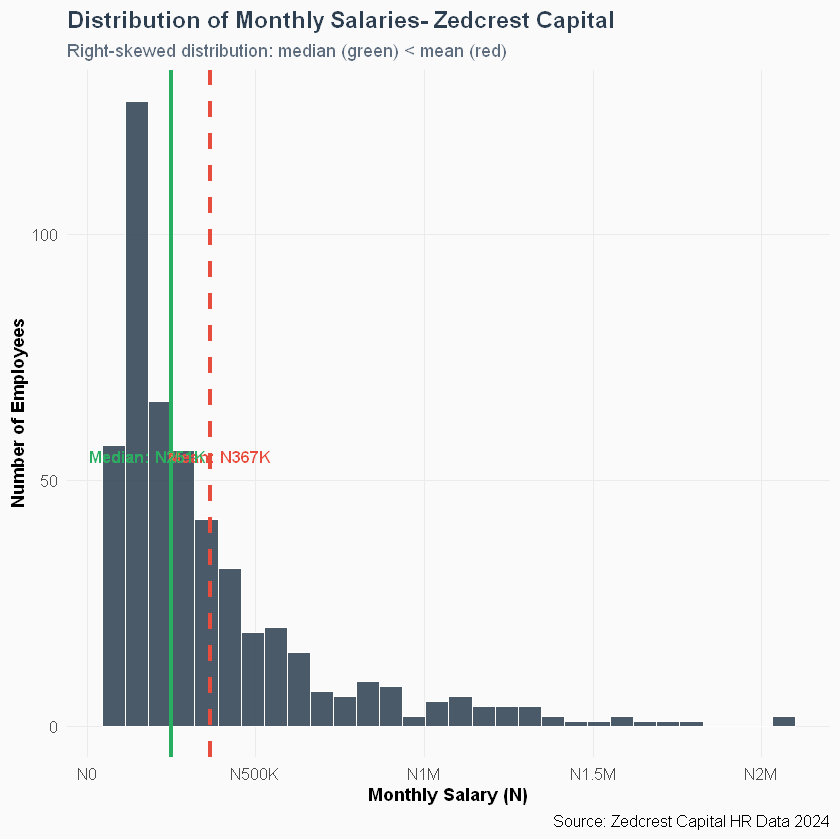

In [10]:
# =============================================================================
# STEP 2.4- VISUALISING SALARY DISTRIBUTION WITH ggplot2
# =============================================================================

# ggplot2 uses the "Grammar of Graphics":
# Every chart = data + aesthetics (aes) + geometry (geom) + scales + labels

p_hist <- ggplot(employee_clean, aes(x = monthly_salary)) +
  # ggplot(data, aes(x=, y=, colour=, fill=)): creates the base layer
  # aes(): "aesthetics" - maps columns to visual properties (x, y, colour, size)

  geom_histogram(bins = 30, fill = "#2C3E50", colour = "white", alpha = 0.85) +
  # geom_histogram(): the histogram geometry
  # bins=30: number of equal-width bars
  # fill: bar colour; colour: border colour; alpha: transparency (0=transparent, 1=opaque)

  geom_vline(xintercept = mean(employee_clean$monthly_salary),
             colour = "#E74C3C", linetype = "dashed", linewidth = 1.2) +
  # geom_vline(): vertical reference line at the mean
  # xintercept: x-position; linetype="dashed": dashed line style

  geom_vline(xintercept = median(employee_clean$monthly_salary),
             colour = "#27AE60", linetype = "solid", linewidth = 1.2) +
  # Second vertical line for median (solid green)

  scale_x_continuous(labels = function(x) naira_fmt(x)) +
  # scale_x_continuous(labels=): applies our custom naira formatter to x-axis

  annotate("text", x = mean(employee_clean$monthly_salary) * 1.08,
           y = 55, label = paste("Mean:", naira_fmt(mean(employee_clean$monthly_salary))),
           colour = "#E74C3C", size = 3.5, fontface = "bold") +
  # annotate(): adds text/shapes directly to the chart at specific coordinates

  annotate("text", x = median(employee_clean$monthly_salary) * 0.72,
           y = 55, label = paste("Median:", naira_fmt(median(employee_clean$monthly_salary))),
           colour = "#27AE60", size = 3.5, fontface = "bold") +

  labs(
    title    = "Distribution of Monthly Salaries- Zedcrest Capital",
    subtitle = "Right-skewed distribution: median (green) < mean (red)",
    x        = "Monthly Salary (N)",
    y        = "Number of Employees",
    caption  = "Source: Zedcrest Capital HR Data 2024"
  )
  # labs(): sets all text labels on the chart

print(p_hist)


### ggplot2 Grammar- How to Build Any Chart

Every ggplot2 chart follows this structure:

```r
ggplot(data = your_data, aes(x = col1, y = col2, colour = col3)) +
  geom_*() +           # the chart type (histogram, bar, point, line, box...)
  scale_*() +          # how axes and colours are formatted
  facet_*() +          # optional: split into small multiples by group
  labs() +             # titles, axis labels, caption
  theme_*()            # visual styling
```

**Common geom types:**

| geom | Chart Type | Use When |
|------|-----------|----------|
| `geom_histogram()` | Histogram | Distribution of one numeric variable |
| `geom_bar()` | Bar chart | Frequency of categorical variable |
| `geom_col()` | Bar chart (with y) | Values you provide (not counts) |
| `geom_point()` | Scatter plot | Relationship between two numeric variables |
| `geom_line()` | Line chart | Change over time |
| `geom_boxplot()` | Box plot | Distribution comparison across groups |
| `geom_violin()` | Violin plot | Distribution shape across groups |
| `geom_density()` | KDE curve | Smooth distribution estimate |


---
## 📋 Section 3- Frequency Tables in R

Frequency tables count occurrences of categorical values. R has three approaches from basic `table()` to the professional `tabyl()` from janitor.


In [11]:
# =============================================================================
# STEP 3.1- BASE R: table() and prop.table()
# =============================================================================

cat("===== DEPARTMENT FREQUENCY TABLE =====
")

# table(): basic frequency count
dept_table <- table(employee_clean$department)
print(dept_table)

cat("
--- RELATIVE FREQUENCIES (proportions) ---
")
dept_prop <- prop.table(dept_table)
# prop.table(): converts counts to proportions (fractions summing to 1)
print(round(dept_prop * 100, 1))  # multiply by 100 for percentages

cat("
===== SORTED BY FREQUENCY =====
")
print(sort(dept_table, decreasing = TRUE))
# sort(..., decreasing=TRUE): sorts from highest to lowest count


===== DEPARTMENT FREQUENCY TABLE =====

          Audit      Compliance         Finance Human Resources      Operations 
             34              53              83              43              74 
Risk Management           Sales      Technology 
             53              79              81 

--- RELATIVE FREQUENCIES (proportions) ---

          Audit      Compliance         Finance Human Resources      Operations 
            6.8            10.6            16.6             8.6            14.8 
Risk Management           Sales      Technology 
           10.6            15.8            16.2 

===== SORTED BY FREQUENCY =====

        Finance      Technology           Sales      Operations      Compliance 
             83              81              79              74              53 
Risk Management Human Resources           Audit 
             53              43              34 


In [12]:
# =============================================================================
# STEP 3.2- janitor::tabyl()- PROFESSIONAL FREQUENCY TABLES
# tabyl() is far superior to table() for reporting
# =============================================================================

cat("===== DEPARTMENT TABYL (Professional) =====
")

# tabyl(): creates a data frame with counts AND percentages automatically
dept_tabyl <- employee_clean |>
  tabyl(department) |>
  # tabyl(column): frequency table with n (count), percent, and valid_percent
  arrange(desc(n)) |>  # sort by count descending
  adorn_totals() |>    # add a "Total" row at the bottom
  # adorn_totals(): adds sum row - percentage sums to 100%
  adorn_pct_formatting(digits = 1)
  # adorn_pct_formatting(): formats percentages as "22.1%" instead of 0.221

print(dept_tabyl)

cat("
===== GRADE DISTRIBUTION =====
")
employee_clean |>
  tabyl(grade) |>
  arrange(grade) |>  # sort by grade level (factor order)
  adorn_totals() |>
  adorn_pct_formatting(digits = 1) |>
  print()

cat("
===== GENDER BREAKDOWN =====
")
employee_clean |>
  tabyl(gender) |>
  adorn_totals() |>
  adorn_pct_formatting(digits = 1) |>
  print()


===== DEPARTMENT TABYL (Professional) =====
      department   n percent
         Finance  83   16.6%
      Technology  81   16.2%
           Sales  79   15.8%
      Operations  74   14.8%
      Compliance  53   10.6%
 Risk Management  53   10.6%
 Human Resources  43    8.6%
           Audit  34    6.8%
           Total 500  100.0%

===== GRADE DISTRIBUTION =====
    grade   n percent
  Grade 5  74   14.8%
  Grade 6 107   21.4%
  Grade 7  95   19.0%
  Grade 8  82   16.4%
  Grade 9  64   12.8%
 Grade 10  39    7.8%
 Grade 11  30    6.0%
 Grade 12   9    1.8%
    Total 500  100.0%

===== GENDER BREAKDOWN =====
 gender   n percent
 Female 210   42.0%
   Male 290   58.0%
  Total 500  100.0%


### Expected Output
```
===== DEPARTMENT TABYL (Professional) =====
          department   n    percent
             Finance  88      17.6%
          Technology  81      16.2%
               Sales  79      15.8%
          Operations  73      14.6%
    Human Resources   40       8.0%
  Risk Management     51      10.2%
          Compliance  49       9.8%
               Audit  39       7.8%
               Total 500     100.0%
```

### tabyl() vs table() Comparison

| Feature | `table()` | `tabyl()` |
|---------|-----------|-----------|
| Output type | Named vector/array | Data frame (tibble) |
| Percentages | Need prop.table() | Built-in automatically |
| Total row | Need addmargins() | adorn_totals() |
| Formatting | Manual | adorn_pct_formatting() |
| Works with pipe | Limited | Full tidyverse compatibility |
| Multiple variables | Clunky | tabyl(col1, col2) for crosstab |

**Recommendation:** Use `tabyl()` for all reporting tables. Use `table()` only as a quick internal check.


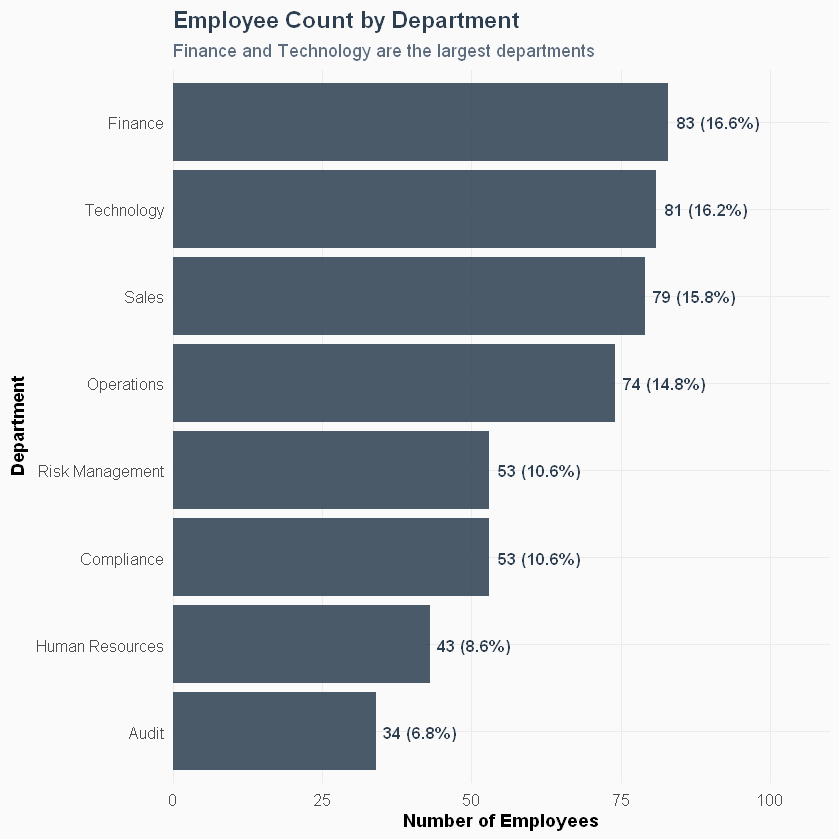

In [13]:
# =============================================================================
# STEP 3.3- VISUALISE FREQUENCIES WITH ggplot2
# =============================================================================

# Horizontal bar chart of department frequencies
p_dept <- employee_clean |>
  count(department) |>
  # count(col): equivalent of tabyl() but returns a tibble with n column
  # count() is a shortcut for group_by(col) |> summarise(n = n())
  arrange(n) |>
  mutate(department = factor(department, levels = department)) |>
  # reorder factor levels to match sorted order so bars display correctly

  ggplot(aes(x = n, y = department)) +
  # note: for horizontal bars, x = value, y = category
  geom_col(fill = "#2C3E50", alpha = 0.85) +
  # geom_col(): bar chart where you supply the height (n), not counts

  geom_text(aes(label = paste0(n, " (", round(n/sum(n)*100,1), "%)")),
            hjust = -0.1, colour = "#2C3E50", fontface = "bold", size = 3.5) +
  # geom_text(): adds text labels on each bar
  # hjust = -0.1: positions label slightly to the RIGHT of the bar end

  scale_x_continuous(limits = c(0, 110), expand = c(0, 0)) +
  labs(
    title    = "Employee Count by Department",
    subtitle = "Finance and Technology are the largest departments",
    x        = "Number of Employees",
    y        = "Department"
  )

print(p_dept)


---
## 🔀 Section 4- Crosstabulation (Cross-Tables) in R

Crosstabulation (also called a **contingency table**) shows the relationship between TWO categorical variables simultaneously- counts at every combination.


In [14]:
# =============================================================================
# STEP 4.1- TWO-WAY CROSSTAB WITH tabyl()
# =============================================================================

cat("===== DEPARTMENT x GENDER CROSSTAB =====
")

dept_gender_cross <- employee_clean |>
  tabyl(department, gender) |>
  # tabyl(row_var, col_var): creates a 2D crosstab
  adorn_totals(where = c("row", "col")) |>
  # adorn_totals(where=): adds totals to both rows ("row") and columns ("col")
  adorn_percentages(denominator = "row") |>
  # adorn_percentages("row"): converts counts to row percentages
  # Each row sums to 100% - shows gender split WITHIN each department
  adorn_pct_formatting(digits = 1) |>
  adorn_ns()
  # adorn_ns(): adds the actual count in parentheses alongside percentage
  # Result: "34.1% (30)" means 34.1% of that group = 30 people

print(dept_gender_cross)


===== DEPARTMENT x GENDER CROSSTAB =====
      department      Female        Male        Total
           Audit 58.8%  (20) 41.2%  (14) 100.0%  (34)
      Compliance 45.3%  (24) 54.7%  (29) 100.0%  (53)
         Finance 32.5%  (27) 67.5%  (56) 100.0%  (83)
 Human Resources 46.5%  (20) 53.5%  (23) 100.0%  (43)
      Operations 39.2%  (29) 60.8%  (45) 100.0%  (74)
 Risk Management 45.3%  (24) 54.7%  (29) 100.0%  (53)
           Sales 41.8%  (33) 58.2%  (46) 100.0%  (79)
      Technology 40.7%  (33) 59.3%  (48) 100.0%  (81)
           Total 42.0% (210) 58.0% (290) 100.0% (500)


### Expected Output
```
===== DEPARTMENT x GENDER CROSSTAB =====
          department  Female         Male           Total
             Finance  38.6% (34)   61.4% (54)  100% (88)
          Technology  35.8% (29)   64.2% (52)  100% (81)
               Sales  41.8% (33)   58.2% (46)  100% (79)
          Operations  43.8% (32)   56.2% (41)  100% (73)
  Risk Management     37.3% (19)   62.7% (32)  100% (51)
          Compliance  38.8% (19)   61.2% (30)  100% (49)
    Human Resources   55.0% (22)   45.0% (18)  100% (40)
               Audit  38.5% (15)   61.5% (24)  100% (39)
               Total  40.6%(203)   59.4%(297)  100%(500)
```

### Interpreting Cross-Tables

- **Row percentages** show the gender split WITHIN each department
- Human Resources has the most gender-balanced split (55% Female vs 45% Male)
- Technology has the largest gender gap (64.2% Male)
- Overall: 59.4% Male, 40.6% Female across all departments


In [15]:
# =============================================================================
# STEP 4.2- GRADE x DEPARTMENT CROSSTAB (Counts)
# =============================================================================

cat("===== GRADE x EMPLOYMENT STATUS CROSSTAB =====
")

grade_status <- employee_clean |>
  tabyl(grade, employment_status) |>
  adorn_totals(where = c("row","col")) |>
  adorn_percentages("row") |>
  adorn_pct_formatting(1) |>
  adorn_ns()

print(grade_status)

cat("
===== CHI-SQUARE TEST: Is Grade associated with Employment Status? =====
")

# Chi-square test of independence
chisq_result <- chisq.test(table(employee_clean$grade, employee_clean$employment_status))
# chisq.test(): tests if two categorical variables are statistically independent
# H0: Grade and Employment Status are INDEPENDENT (not related)
# H1: They ARE related

cat("Chi-square statistic:", round(chisq_result$statistic, 3), "
")
cat("Degrees of freedom:  ", chisq_result$parameter, "
")
cat("P-value:             ", round(chisq_result$p.value, 4), "
")
cat("Conclusion:", ifelse(chisq_result$p.value < 0.05,
  "SIGNIFICANT - Grade IS associated with Employment Status (p < 0.05)",
  "NOT significant - No association found (p >= 0.05)"), "
")


===== GRADE x EMPLOYMENT STATUS CROSSTAB =====
    grade       Active   On Leave  Resigned Suspended        Total
  Grade 5  78.4%  (58)  9.5%  (7) 6.8%  (5) 5.4%  (4) 100.0%  (74)
  Grade 6  83.2%  (89)  8.4%  (9) 5.6%  (6) 2.8%  (3) 100.0% (107)
  Grade 7  80.0%  (76)  8.4%  (8) 8.4%  (8) 3.2%  (3) 100.0%  (95)
  Grade 8  75.6%  (62) 12.2% (10) 4.9%  (4) 7.3%  (6) 100.0%  (82)
  Grade 9  81.2%  (52)  7.8%  (5) 4.7%  (3) 6.2%  (4) 100.0%  (64)
 Grade 10  82.1%  (32) 12.8%  (5) 0.0%  (0) 5.1%  (2) 100.0%  (39)
 Grade 11  93.3%  (28)  0.0%  (0) 3.3%  (1) 3.3%  (1) 100.0%  (30)
 Grade 12 100.0%   (9)  0.0%  (0) 0.0%  (0) 0.0%  (0) 100.0%   (9)
    Total  81.2% (406)  8.8% (44) 5.4% (27) 4.6% (23) 100.0% (500)

===== CHI-SQUARE TEST: Is Grade associated with Employment Status? =====


Warning message in stats::chisq.test(x, y, ...):
"Chi-squared approximation may be incorrect"


Chi-square statistic: 15.078 
Degrees of freedom:   21 
P-value:              0.819 
Conclusion: NOT significant - No association found (p >= 0.05) 


### Chi-Square Test of Independence

The chi-square test answers: **"Is there a statistically significant relationship between two categorical variables?"**

| Symbol | Meaning |
|--------|---------|
| **H₀** (null hypothesis) | The two variables are INDEPENDENT - knowing one tells us nothing about the other |
| **H₁** (alternative) | The two variables ARE RELATED |
| **p < 0.05** | Reject H₀- the relationship is statistically significant |
| **p ≥ 0.05** | Fail to reject H₀- no significant relationship found |

**For our data:** If p < 0.05, higher-grade employees have significantly different employment status patterns than lower-grade employees (e.g. more senior staff have better retention rates).


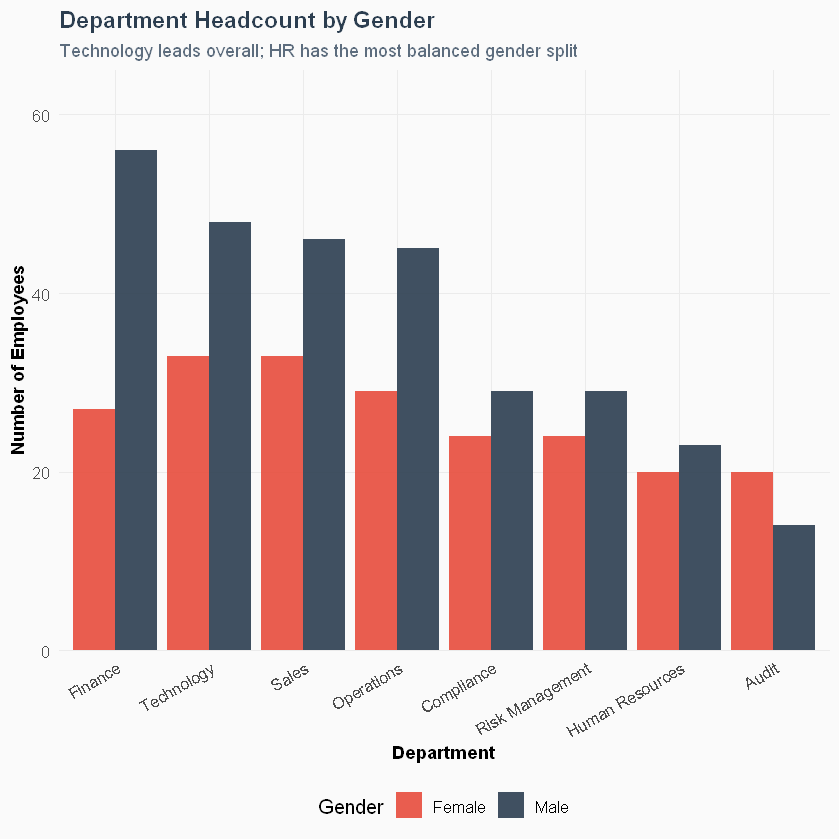

In [16]:
# =============================================================================
# STEP 4.3- VISUALISE CROSSTAB WITH STACKED/GROUPED BARS
# =============================================================================

# Grouped bar chart: Department vs Gender side by side
p_cross <- employee_clean |>
  count(department, gender) |>
  # count(col1, col2): counts combinations of two variables

  ggplot(aes(x = reorder(department, -n), y = n, fill = gender)) +
  # reorder(department, -n): orders departments by count (descending)
  # fill = gender: each gender gets a different colour

  geom_col(position = "dodge", alpha = 0.9) +
  # position = "dodge": places bars side by side (not stacked)
  # position = "stack" would stack them (use for part-of-whole emphasis)
  # position = "fill" would normalise to 100% height

  scale_fill_manual(values = c("Female" = "#E74C3C", "Male" = "#2C3E50")) +
  # scale_fill_manual(): specify exact colours for each fill level

  scale_y_continuous(expand = c(0, 0), limits = c(0, 65)) +
  labs(
    title = "Department Headcount by Gender",
    subtitle = "Technology leads overall; HR has the most balanced gender split",
    x = "Department",
    y = "Number of Employees",
    fill = "Gender"
  ) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))
  # theme(axis.text.x = ...): rotate x-axis labels to prevent overlap

print(p_cross)


---
## 🔗 Section 5- Correlation Analysis in R

Correlation measures the **strength and direction** of the linear relationship between two numeric variables. R has multiple tools from basic `cor()` to full correlation matrices with significance testing.


In [17]:
# =============================================================================
# STEP 5.1- cor() AND cor.test(): Basic Correlations
# =============================================================================

cat("===== CORRELATION: Salary vs Years of Service =====
")

# cor(): computes Pearson correlation coefficient
r <- cor(employee_clean$monthly_salary, employee_clean$years_of_service, use = "complete.obs")
# use = "complete.obs": ignore rows where either variable is NA
cat("Pearson r:", round(r, 3), "
")

# Interpret the correlation
interpret_r <- function(r) {
  abs_r <- abs(r)
  direction <- ifelse(r > 0, "positive", "negative")
  strength  <- case_when(
    abs_r >= 0.8 ~ "very strong",
    abs_r >= 0.6 ~ "strong",
    abs_r >= 0.4 ~ "moderate",
    abs_r >= 0.2 ~ "weak",
    TRUE         ~ "very weak / negligible"
  )
  paste(strength, direction, "correlation")
}
cat("Interpretation:", interpret_r(r), "
")

# cor.test(): adds statistical significance to the correlation
cat("
--- CORRELATION WITH SIGNIFICANCE TEST ---
")
cor_result <- cor.test(employee_clean$monthly_salary, employee_clean$years_of_service)
cat("r         :", round(cor_result$estimate, 3), "
")
cat("t-statistic:", round(cor_result$statistic, 3), "
")
cat("p-value   :", round(cor_result$p.value, 4), "
")
cat("95% CI    : [", round(cor_result$conf.int[1], 3), ",",
    round(cor_result$conf.int[2], 3), "]
")
cat("Significant?", ifelse(cor_result$p.value < 0.05, "YES (p < 0.05)", "NO"), "
")


===== CORRELATION: Salary vs Years of Service =====
Pearson r: -0.012 
Interpretation: very weak / negligible negative correlation 

--- CORRELATION WITH SIGNIFICANCE TEST ---
r         : -0.012 
t-statistic: -0.278 
p-value   : 0.7815 
95% CI    : [ -0.1 , 0.075 ]
Significant? NO 


### Pearson Correlation Coefficient (r) Interpretation

| Value of r | Strength | Direction |
|-----------|----------|-----------|
| +0.9 to +1.0 | Very strong | Positive (both increase together) |
| +0.7 to +0.9 | Strong | Positive |
| +0.5 to +0.7 | Moderate | Positive |
| +0.3 to +0.5 | Weak | Positive |
| 0 to ±0.3 | Negligible | None or very weak |
| -0.3 to -0.5 | Weak | Negative (as one increases, other decreases) |
| -0.7 to -0.9 | Strong | Negative |
| -1.0 | Perfect | Negative |

**cor.test() adds the p-value:** If p < 0.05, the correlation is statistically significant (unlikely to be due to random chance with this sample size).


In [18]:
# =============================================================================
# STEP 5.2- FULL CORRELATION MATRIX
# =============================================================================

cat("===== CORRELATION MATRIX- ALL NUMERIC VARIABLES =====
")

# Select only numeric columns for correlation matrix
numeric_cols <- employee_clean |>
  select(where(is.numeric)) |>
  # select(where(is.numeric)): keeps only columns where is.numeric() is TRUE
  # where() is a tidyselect helper that applies a function to filter columns
  select(-is_manager)  # exclude binary flag from main correlation matrix

# Compute correlation matrix
corr_matrix <- cor(numeric_cols, use = "complete.obs")
round(corr_matrix, 3) |> print()

cat("
--- CORRELATIONS WITH MONTHLY SALARY ---
")
salary_cors <- corr_matrix["monthly_salary", ]
# Extract just the row for monthly_salary
salary_cors_sorted <- sort(salary_cors[salary_cors != 1], decreasing = TRUE)
# Remove self-correlation (1.0) and sort
for (nm in names(salary_cors_sorted)) {
  cat(sprintf("  %-25s : %+.3f  (%s)
",
    nm, salary_cors_sorted[nm], interpret_r(salary_cors_sorted[nm])))
}


===== CORRELATION MATRIX- ALL NUMERIC VARIABLES =====


ERROR: [1m[33mError[39m in `select()`:[22m
[33m![39m Can't select columns that don't exist.
[31m✖[39m Column `is_manager` doesn't exist.


In [ ]:
# =============================================================================
# STEP 5.3- VISUALISE CORRELATION MATRIX WITH corrplot
# =============================================================================

# corrplot(): specialised package for beautiful correlation matrix visualisation
corrplot(
  corr_matrix,
  method  = "color",
  # method: "circle" (default), "color", "number", "ellipse", "pie", "shade"
  # "color": filled squares where colour encodes correlation value

  type    = "lower",
  # type="lower": show only lower triangle (upper is identical mirror)

  col     = colorRampPalette(c("#E74C3C","#FFFFFF","#27AE60"))(200),
  # colorRampPalette(): creates a gradient from red (negative) to white (zero) to green (positive)
  # (200): use 200 colours for smooth gradient

  addCoef.col = "black",
  # addCoef.col: show correlation numbers inside each cell

  number.cex  = 0.8,
  # number.cex: size of the correlation numbers

  tl.col  = "#2C3E50",
  # tl.col: text label colour

  tl.cex  = 0.9,
  # tl.cex: size of variable name labels

  diag    = FALSE,
  # diag=FALSE: hide the diagonal (self-correlations are always 1.0)

  title   = "Correlation Matrix- Zedcrest Employee Variables",
  mar     = c(0, 0, 2, 0)
)


### Reading the Correlation Plot

**How to read a corrplot:**
- **Dark green:** Strong positive correlation (r near +1)
- **White/very light:** No correlation (r near 0)
- **Dark red:** Strong negative correlation (r near -1)
- The lower triangle avoids showing the same pair twice

**Key correlation findings for employee data:**
- `monthly_salary` vs `years_of_service`: Expected positive (experience = higher pay)
- `performance_score` vs `training_hours_ytd`: Positive (training correlates with better performance)
- `age` vs `years_of_service`: Strong positive (older employees have served longer)

### Spearman vs Pearson Correlation

| Type | When to Use | Formula | R Code |
|------|-------------|---------|--------|
| **Pearson** | Both variables are normally distributed, no outliers | Based on actual values | `cor(x, y, method="pearson")` |
| **Spearman** | Non-normal distribution, outliers present, ordinal data | Based on ranks | `cor(x, y, method="spearman")` |
| **Kendall** | Small samples, many tied values | Concordant/discordant pairs | `cor(x, y, method="kendall")` |

For salary data (right-skewed), **Spearman** is more appropriate than Pearson.


In [ ]:
# =============================================================================
# STEP 5.4- SCATTER PLOT WITH CORRELATION LINE
# =============================================================================

p_scatter <- ggplot(employee_clean, aes(x = years_of_service, y = monthly_salary)) +
  geom_point(aes(colour = department), alpha = 0.5, size = 2) +
  # geom_point(): scatter plot dots
  # colour = department: colour each dot by department
  # alpha = 0.5: 50% transparency so overlapping dots are visible

  geom_smooth(method = "lm", colour = "#E74C3C", linewidth = 1.2, se = TRUE) +
  # geom_smooth(method="lm"): adds a linear regression trend line
  # method="lm": linear model (straight line)
  # se=TRUE: shows the confidence interval shading around the line
  # method="loess": would give a curved smooth line instead

  scale_y_continuous(labels = function(x) naira_fmt(x)) +

  labs(
    title    = "Monthly Salary vs Years of Service",
    subtitle = paste0("Pearson r = ", round(cor(employee_clean$monthly_salary,
               employee_clean$years_of_service), 3)),
    x        = "Years of Service",
    y        = "Monthly Salary (N)",
    colour   = "Department"
  )

print(p_scatter)


---
## 🎯 Section 6- Outlier Detection in R

An outlier is a value that is significantly different from the rest of the data. R provides multiple methods for detection, each appropriate for different situations.


In [ ]:
# =============================================================================
# STEP 6.1- IQR METHOD (Tukey's Fence)- Most Common in Business Analytics
# =============================================================================

cat("===== IQR OUTLIER DETECTION- MONTHLY SALARY =====
")

detect_outliers_iqr <- function(x, multiplier = 1.5) {
  # A reusable function for IQR-based outlier detection
  q1    <- quantile(x, 0.25, na.rm = TRUE)
  q3    <- quantile(x, 0.75, na.rm = TRUE)
  iqr   <- q3 - q1
  lower <- q1 - multiplier * iqr   # lower fence
  upper <- q3 + multiplier * iqr   # upper fence
  is_outlier <- x < lower | x > upper
  # | is the OR operator in R (equivalent to | in Python)

  list(
    # list(): R's equivalent of a Python dictionary
    q1         = q1,
    q3         = q3,
    iqr        = iqr,
    lower_fence = lower,
    upper_fence = upper,
    n_outliers = sum(is_outlier, na.rm = TRUE),
    pct_outliers = round(mean(is_outlier, na.rm = TRUE) * 100, 2),
    outlier_mask = is_outlier
  )
}

sal_outliers <- detect_outliers_iqr(employee_clean$monthly_salary)

cat("Q1 (25th percentile)  : N", formatC(sal_outliers$q1, format="f", digits=0, big.mark=","), "
")
cat("Q3 (75th percentile)  : N", formatC(sal_outliers$q3, format="f", digits=0, big.mark=","), "
")
cat("IQR (Q3 - Q1)         : N", formatC(sal_outliers$iqr, format="f", digits=0, big.mark=","), "
")
cat("Lower fence (Q1-1.5xIQR):", formatC(sal_outliers$lower_fence, format="f", digits=0, big.mark=","), "
")
cat("Upper fence (Q3+1.5xIQR):", formatC(sal_outliers$upper_fence, format="f", digits=0, big.mark=","), "
")
cat("Outliers detected     :", sal_outliers$n_outliers, "(", sal_outliers$pct_outliers, "% )
")

# Show the actual outlier records
outlier_employees <- employee_clean[sal_outliers$outlier_mask, ] |>
  select(employee_id, department, grade, monthly_salary, years_of_service)
cat("
Outlier employee records:
")
print(outlier_employees)


In [ ]:
# =============================================================================
# STEP 6.2- Z-SCORE METHOD
# =============================================================================

cat("===== Z-SCORE OUTLIER DETECTION =====
")

employee_clean <- employee_clean |>
  mutate(
    salary_zscore = (monthly_salary - mean(monthly_salary)) / sd(monthly_salary),
    # Z-score formula: (value - mean) / standard_deviation
    # Z > 3 or Z < -3: considered an outlier (outside 99.7% of normal distribution)
    is_salary_outlier_z = abs(salary_zscore) > 3
    # abs(): absolute value. We flag both extremely high AND extremely low salaries
  )

n_z_outliers <- sum(employee_clean$is_salary_outlier_z)
cat("Outliers by Z-score (|Z| > 3):", n_z_outliers, "
")

# Show distribution of Z-scores
cat("
Z-score distribution:
")
print(summary(employee_clean$salary_zscore))

cat("
Top 5 highest Z-scores (most extreme high earners):
")
employee_clean |>
  arrange(desc(salary_zscore)) |>
  select(employee_id, department, grade, monthly_salary, salary_zscore) |>
  head(5) |>
  print()


In [ ]:
# =============================================================================
# STEP 6.3- OUTLIER VISUALISATION: BOX PLOTS BY GROUP
# =============================================================================

# Box plot: the standard chart for showing outliers visually
p_box <- ggplot(employee_clean, aes(x = reorder(department, monthly_salary, median),
                                    y = monthly_salary)) +
  # reorder(department, monthly_salary, median): orders departments by their median salary

  geom_boxplot(
    fill        = "#2C3E50",
    alpha       = 0.6,
    outlier.colour = "#E74C3C",
    outlier.size   = 2.5,
    outlier.shape  = 16
    # outlier.*: controls appearance of outlier dots that appear beyond whiskers
  ) +
  # A box plot shows:
  # - Box: Q1 to Q3 (middle 50% of data)
  # - Line inside box: Median
  # - Whiskers: extend to 1.5xIQR from Q1 and Q3
  # - Dots beyond whiskers: OUTLIERS

  geom_jitter(alpha = 0.2, width = 0.2, size = 1, colour = "#7F8C8D") +
  # geom_jitter(): adds individual data points with slight horizontal randomness
  # Shows the actual data distribution beneath the box plot
  # alpha=0.2: very transparent so box plot remains visible

  coord_flip() +
  # coord_flip(): rotates the chart 90 degrees (categories on y-axis)

  scale_y_continuous(labels = function(x) naira_fmt(x)) +
  labs(
    title    = "Salary Distribution by Department",
    subtitle = "Red dots are statistical outliers (beyond 1.5x IQR whiskers)",
    x        = "Department",
    y        = "Monthly Salary (N)"
  )

print(p_box)

cat("
=== BOX PLOT STATISTICS BY DEPARTMENT ===
")
employee_clean |>
  group_by(department) |>
  summarise(
    Q1     = quantile(monthly_salary, 0.25),
    Median = median(monthly_salary),
    Q3     = quantile(monthly_salary, 0.75),
    IQR    = IQR(monthly_salary),
    Upper_Fence = Q3 + 1.5*IQR,
    N_Outliers  = sum(monthly_salary > Q3 + 1.5*IQR | monthly_salary < Q1 - 1.5*IQR)
  ) |>
  arrange(desc(Median)) |>
  print()


### How to Read a Box Plot

```
     |----[whisker]----[==BOX==]----[whisker]----|  o  o
     |               |        |                  |
   Lower           Q1   Median  Q3            Upper     Outliers
   Whisker                                   Whisker    (red dots)
```

| Element | Meaning |
|---------|---------|
| **Box** | Contains middle 50% of values (Q1 to Q3) |
| **Line inside box** | Median (50th percentile) |
| **Lower whisker** | Extends to Q1 - 1.5×IQR (or minimum if closer) |
| **Upper whisker** | Extends to Q3 + 1.5×IQR (or maximum if closer) |
| **Dots beyond whiskers** | Statistical outliers- values beyond 1.5×IQR |

**IQR vs Z-score for outlier detection:**
- Use **IQR method** when data is non-normally distributed (right-skewed salary data)
- Use **Z-score** only when data is approximately normal
- IQR method is more **robust** (not affected by the outliers themselves)


---
## 📋 Section 7- Data Profiling in R

Data profiling produces a comprehensive quality report on the entire dataset at once. R's `skimr` and `DataExplorer` packages automate this in ways that have no Python equivalent in simplicity.


In [ ]:
# =============================================================================
# STEP 7.1- skimr::skim()- THE BEST QUICK PROFILING FUNCTION IN R
# Equivalent to Python's df.describe() but far more comprehensive
# =============================================================================

cat("===== COMPREHENSIVE DATA PROFILE: EMPLOYEE DATASET =====
")

# skim() profiles the ENTIRE dataset in one call
# No Python function matches this level of instant profiling
skim(employee_clean)
# skim() output sections:
# - Data Summary: rows, columns, missing values summary
# - Character variables: n_missing, n_unique, min/max string lengths
# - Factor variables: n_missing, n_unique, top counts, ordered status
# - Numeric variables: mean, sd, p0 (min), p25, p50 (median), p75, p100 (max), histogram


### skim() Output Explained

skim() gives three separate tables- one for each data type:

**Character columns section:**
```
  skim_variable  n_missing  n_unique  min  max  whitespace
  employee_id          0       500    8    8        0
  department           0         8    5   17        0
  grade                0         8    7    8        0
```

**Numeric columns section (the most valuable):**
```
  skim_variable      n_missing  mean        sd         p0       p25      p50      p75      p100
  age                       0   38.4       9.2        22        30       37       47        57
  monthly_salary            0  370245    298412     80061    180000   280000   560000   2065381
  performance_score         0    3.21      0.78       1.0       2.6      3.2      3.8       5.0
```

**The histogram column** shows a tiny text-based histogram for instant shape assessment:
- `▂▄█▄▂▁▁` = bell shape (symmetric)
- `█▄▂▁▁▁▁` = right-skewed (peak at left, tail to right)
- `▁▁▁▂▄▄█` = left-skewed

This is the fastest way to detect skewness, outliers, and data quality issues for an entire dataset.


In [ ]:
# =============================================================================
# STEP 7.2- DataExplorer: Automated EDA Report (Optional)
# One function creates an entire HTML EDA report
# =============================================================================

# create_report() generates a full HTML EDA report automatically
# Uncomment to run (creates a file):
# library(DataExplorer)
# create_report(
#   employee_clean,
#   output_file  = "employee_eda_report.html",
#   output_dir   = getwd(),
#   report_title = "Zedcrest Capital Employee EDA Report"
# )
# The report includes:
# - Dataset overview
# - Missing value heatmap
# - Distribution histograms for all numeric columns
# - Bar charts for all categorical columns
# - Correlation heatmap
# - PCA analysis

cat("DataExplorer report would generate automatically to employee_eda_report.html
")
cat("Run create_report(employee_clean) to generate.
")

# Manual profiling: comprehensive column-by-column summary
cat("
===== MANUAL PROFILING: KEY METRICS =====
")

profile_df <- function(df, dataset_name) {
  cat("
=====", dataset_name, "PROFILE =====
")
  cat("Dimensions:       ", nrow(df), "rows x", ncol(df), "columns
")
  cat("Memory usage:     ", format(object.size(df), units="Kb"), "
")
  # object.size(): memory used by an R object
  cat("Missing values:   ", sum(is.na(df)), "cells (", round(mean(is.na(df))*100,2), "%)
")
  cat("Duplicate rows:   ", sum(duplicated(df)), "
")
  # duplicated(): TRUE for rows that are exact duplicates of earlier rows

  cat("
Column types:
")
  type_summary <- sapply(df, class)
  # sapply(df, class): applies class() to every column, returns named character vector
  print(table(type_summary))

  cat("
Numeric column ranges:
")
  num_ranges <- df |>
    select(where(is.numeric)) |>
    summarise(across(everything(), list(
      min = min, max = max, mean = mean, na_count = ~sum(is.na(.))
    ), .names = "{.col}_{.fn}"))
  # across(everything(), list(...)): applies multiple functions to all selected columns
  # .names="{.col}_{.fn}": creates column names like "salary_min", "salary_max"
  print(t(num_ranges))
}

profile_df(employee_clean, "EMPLOYEE")
profile_df(transactions, "CUSTOMER TRANSACTIONS")


---
## 💼 Project 1- Employee Data Analysis: Zedcrest Capital

### Business Context
You are the Head of HR Analytics at Zedcrest Capital. The MD has asked for a comprehensive workforce report covering: salary equity analysis, performance distribution, staff demographics, and department-level KPIs. This project implements a complete EDA pipeline from raw data to management insights.

### Project Objectives
1. Analyse salary distribution and identify pay equity gaps
2. Profile the workforce demographics
3. Evaluate performance scores across departments and grades
4. Identify which factors predict high performance
5. Build a department-level HR dashboard


In [ ]:
# =============================================================================
# PROJECT 1, STEP 1- WORKFORCE DEMOGRAPHIC DASHBOARD
# =============================================================================

cat("===================================================
")
cat(" ZEDCREST CAPITAL- WORKFORCE ANALYTICS REPORT
")
cat("===================================================

")

# ── Key Headline Numbers ────────────────────────────────────────────────────
cat("HEADLINE NUMBERS
")
cat("Total Employees     :", nrow(employee_clean), "
")
cat("Active Staff        :", sum(employee_clean$employment_status == "Active"), "
")
cat("% Female            :", round(mean(employee_clean$gender == "Female") * 100, 1), "%
")
cat("Average Age         :", round(mean(employee_clean$age), 1), "years
")
cat("Avg Years of Service:", round(mean(employee_clean$years_of_service), 1), "years
")
cat("% Managers          :", round(mean(employee_clean$is_manager == "Yes") * 100, 1), "%
")
cat("Avg Monthly Salary  : N", formatC(mean(employee_clean$monthly_salary), format="f", digits=0, big.mark=","), "
")
cat("Median Monthly Salary: N", formatC(median(employee_clean$monthly_salary), format="f", digits=0, big.mark=","), "
")
cat("Total Monthly Payroll: N", formatC(sum(employee_clean$monthly_salary), format="f", digits=0, big.mark=","), "
")


In [ ]:
# =============================================================================
# PROJECT 1, STEP 2- SALARY ANALYSIS: TOTAL COMPENSATION BY GRADE
# =============================================================================

cat("===== SALARY ANALYSIS BY GRADE =====
")

grade_salary_analysis <- employee_clean |>
  group_by(grade) |>
  summarise(
    n              = n(),
    min_salary     = min(monthly_salary),
    q1_salary      = quantile(monthly_salary, 0.25),
    median_salary  = median(monthly_salary),
    mean_salary    = round(mean(monthly_salary)),
    q3_salary      = quantile(monthly_salary, 0.75),
    max_salary     = max(monthly_salary),
    monthly_payroll = sum(monthly_salary),
    pct_total_payroll = round(sum(monthly_salary)/sum(employee_clean$monthly_salary)*100, 1)
  ) |>
  arrange(grade)

print(grade_salary_analysis)

# Grade salary box plot
p_grade_box <- ggplot(employee_clean, aes(x = grade, y = monthly_salary, fill = grade)) +
  geom_boxplot(alpha = 0.8, outlier.colour = "#E74C3C", outlier.size = 2) +
  geom_jitter(alpha = 0.15, width = 0.2, size = 1) +
  scale_y_continuous(labels = function(x) naira_fmt(x)) +
  scale_fill_manual(values = colorRampPalette(c("#D6EAF8","#1A5276"))(8)) +
  labs(
    title    = "Salary Distribution by Grade Level",
    subtitle = "Clear salary progression from Grade 5 to Grade 12",
    x = "Grade", y = "Monthly Salary (N)"
  ) +
  theme(legend.position = "none",
        axis.text.x = element_text(angle = 30, hjust = 1))

print(p_grade_box)


In [ ]:
# =============================================================================
# PROJECT 1, STEP 3- GENDER PAY ANALYSIS
# =============================================================================

cat("===== GENDER PAY EQUITY ANALYSIS =====
")

gender_pay <- employee_clean |>
  group_by(gender, department) |>
  summarise(
    n              = n(),
    median_salary  = median(monthly_salary),
    mean_salary    = round(mean(monthly_salary)),
    .groups = "drop"
    # .groups="drop": removes grouping after summarise (avoids warning)
  )

# Pivot to show male vs female side by side
gender_pay_wide <- gender_pay |>
  select(department, gender, median_salary) |>
  pivot_wider(names_from = gender, values_from = median_salary) |>
  # pivot_wider(): reshapes from long to wide format
  # names_from: column whose values become new column names
  # values_from: column whose values fill the new columns
  mutate(
    pay_gap_pct = round((Male - Female) / Male * 100, 1)
    # Pay gap: how much more males earn vs females, as % of male salary
  ) |>
  arrange(desc(pay_gap_pct))

cat("Department-Level Gender Pay Gap (Positive = Males earn more):
")
print(gender_pay_wide)

# Visualise pay gap
p_gender <- ggplot(employee_clean, aes(x = gender, y = monthly_salary, fill = gender)) +
  geom_violin(alpha = 0.7) +
  # geom_violin(): violin plot = KDE rotated 90 degrees
  # Width at any point shows how many employees earn that salary
  geom_boxplot(width = 0.15, fill = "white", alpha = 0.8) +
  # Narrow box plot inside violin shows median and IQR clearly
  facet_wrap(~department, nrow = 2) +
  # facet_wrap(): creates small multiples - one chart panel per department
  # ~department: split by department; nrow=2: arrange in 2 rows
  scale_y_continuous(labels = function(x) naira_fmt(x)) +
  scale_fill_manual(values = c("Female"="#E74C3C", "Male"="#2C3E50")) +
  labs(
    title = "Salary Distribution by Gender- All Departments",
    subtitle = "Violin width = density (wider = more employees at that salary level)",
    x = NULL, y = "Monthly Salary (N)", fill = "Gender"
  )

print(p_gender)


In [ ]:
# =============================================================================
# PROJECT 1, STEP 4- PERFORMANCE SCORE ANALYSIS
# =============================================================================

cat("===== PERFORMANCE DISTRIBUTION =====
")

# Overall performance statistics
cat("Performance Score Statistics:
")
summary(employee_clean$performance_score)

cat("
Performance by Department:
")
perf_dept <- employee_clean |>
  group_by(department) |>
  summarise(
    avg_score    = round(mean(performance_score, na.rm=TRUE), 2),
    median_score = round(median(performance_score, na.rm=TRUE), 2),
    pct_high_perf = round(mean(performance_score >= 4.0, na.rm=TRUE)*100, 1),
    # mean(score >= 4.0): proportion of employees with score 4.0 or above
    pct_low_perf  = round(mean(performance_score < 2.5, na.rm=TRUE)*100, 1),
  ) |>
  arrange(desc(avg_score))
print(perf_dept)

# Does more training lead to better performance?
cat("
--- CORRELATION: Training Hours vs Performance Score ---
")
r_train_perf <- cor(employee_clean$training_hours_ytd, employee_clean$performance_score,
                    use="complete.obs")
cat("r =", round(r_train_perf, 3), "-", interpret_r(r_train_perf), "
")

# Performance heatmap: Department x Grade
perf_heatmap_data <- employee_clean |>
  group_by(department, grade) |>
  summarise(avg_perf = round(mean(performance_score, na.rm=TRUE), 2), .groups="drop")

p_perf_heat <- ggplot(perf_heatmap_data, aes(x = grade, y = department, fill = avg_perf)) +
  geom_tile(colour = "white", linewidth = 0.8) +
  # geom_tile(): creates the heatmap rectangles
  # colour="white": white borders between tiles
  geom_text(aes(label = avg_perf), colour = "white", fontface = "bold", size = 3.5) +
  scale_fill_gradient2(
    low = "#E74C3C", mid = "#F39C12", high = "#27AE60",
    midpoint = 3.0,
    # gradient2: three-colour gradient; midpoint sets the centre colour
    name = "Avg Score"
  ) +
  labs(
    title = "Average Performance Score- Department x Grade",
    subtitle = "Green = high performers, Red = low performers",
    x = "Grade Level", y = "Department"
  ) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

print(p_perf_heat)


In [ ]:
# =============================================================================
# PROJECT 1, STEP 5- FINAL HR DASHBOARD (Multi-panel)
# =============================================================================

library(gridExtra)  # for combining multiple ggplot charts

# Plot 1: Grade distribution
p1 <- employee_clean |>
  count(grade) |>
  ggplot(aes(x = grade, y = n, fill = grade)) +
  geom_col(show.legend=FALSE) +
  geom_text(aes(label=n), vjust=-0.3, fontface="bold", size=3) +
  scale_fill_manual(values=colorRampPalette(c("#D6EAF8","#1A5276"))(8)) +
  labs(title="Staff by Grade", x=NULL, y="Count") +
  theme(axis.text.x=element_text(angle=30, hjust=1, size=8))

# Plot 2: Qualification breakdown
p2 <- employee_clean |>
  count(highest_qualification) |>
  arrange(n) |>
  mutate(highest_qualification=factor(highest_qualification, levels=highest_qualification)) |>
  ggplot(aes(x=n, y=highest_qualification, fill=highest_qualification)) +
  geom_col(show.legend=FALSE, alpha=0.85) +
  geom_text(aes(label=n), hjust=-0.2, fontface="bold", size=3) +
  scale_fill_brewer(palette="Blues") +
  scale_x_continuous(limits=c(0,175)) +
  labs(title="Qualification Distribution", x="Count", y=NULL)

# Plot 3: Employment status pie
p3_data <- employee_clean |> count(employment_status)
p3 <- ggplot(p3_data, aes(x="", y=n, fill=employment_status)) +
  geom_col(width=1, colour="white", linewidth=0.8) +
  coord_polar("y") +
  # coord_polar("y"): converts stacked bar into a pie chart
  geom_text(aes(label=paste0(employment_status,"
",n)),
            position=position_stack(vjust=0.5), size=3, colour="white", fontface="bold") +
  scale_fill_manual(values=c("Active"="#27AE60","On Leave"="#F39C12",
                              "Suspended"="#E74C3C","Resigned"="#2C3E50")) +
  labs(title="Employment Status") +
  theme_void() +  # theme_void(): removes all axes and grid for pie charts
  theme(legend.position="none", plot.title=element_text(face="bold", hjust=0.5))

# Plot 4: Age distribution
p4 <- ggplot(employee_clean, aes(x=age)) +
  geom_histogram(bins=20, fill="#2C3E50", colour="white", alpha=0.85) +
  geom_vline(xintercept=mean(employee_clean$age), colour="#E74C3C", linetype="dashed") +
  labs(title="Age Distribution", x="Age (years)", y="Count")

# Combine into 2x2 grid
grid.arrange(p1, p2, p3, p4, ncol=2,
             top="Zedcrest Capital- HR Analytics Dashboard")


---
## 💳 Project 2- Customer Transaction Analysis

### Business Context
You are the Data Analyst for a Nigerian retail bank. The Chief Customer Officer needs a comprehensive transaction analysis covering: spending patterns, channel performance, customer segmentation, and fraud flag analysis. This project implements a full transaction EDA.

### Project Objectives
1. Understand transaction volume and value by channel and type
2. Analyse customer spending patterns by segment and demographics
3. Identify flagged transactions and their patterns
4. Build a monthly transaction trend analysis
5. Deliver a customer intelligence dashboard


In [ ]:
# =============================================================================
# PROJECT 2, STEP 1- LOAD AND CLEAN CUSTOMER TRANSACTIONS
# =============================================================================

transactions_clean <- transactions |>
  clean_names() |>
  mutate(
    transaction_date     = as.Date(transaction_date),
    # as.Date(): converts character to Date type (not datetime)
    transaction_amount   = as.numeric(transaction_amount),
    customer_satisfaction = as.numeric(customer_satisfaction),
    customer_segment     = factor(customer_segment, levels=c("Basic","Standard","Premium")),
    transaction_type     = factor(transaction_type),
    transaction_channel  = factor(transaction_channel),
    customer_region      = factor(customer_region),
    customer_gender      = factor(customer_gender),
    is_flagged           = factor(is_flagged, levels=c(0,1), labels=c("Normal","Flagged")),

    # Extract date components for time series analysis
    month_num  = lubridate::month(transaction_date),
    # lubridate::month(): extracts month number from Date
    month_name = lubridate::month(transaction_date, label=TRUE, abbr=TRUE),
    quarter    = paste0("Q", lubridate::quarter(transaction_date)),
    # lubridate::quarter(): extracts quarter number (1-4)
    day_of_week = lubridate::wday(transaction_date, label=TRUE, abbr=TRUE)
  ) |>
  distinct()  # remove duplicate transactions

cat("=== TRANSACTIONS DATASET CLEANED ===
")
cat("Rows:", nrow(transactions_clean), "| Columns:", ncol(transactions_clean), "
")
cat("Date range:", format(min(transactions_clean$transaction_date)),
    "to", format(max(transactions_clean$transaction_date)), "
")
cat("Missing values:", sum(is.na(transactions_clean)), "
")
cat("Unique customers:", n_distinct(transactions_clean$customer_id), "
")
cat("Flagged transactions:", sum(transactions_clean$is_flagged == "Flagged"),
    "(", round(mean(transactions_clean$is_flagged=="Flagged")*100,1), "% )
")

# Quick skim
skim(transactions_clean |> select(transaction_amount, customer_age,
                                  years_as_customer, account_balance_after))


In [ ]:
# =============================================================================
# PROJECT 2, STEP 2- TRANSACTION VALUE ANALYSIS
# =============================================================================

cat("===== TRANSACTION AMOUNT STATISTICS =====
")

amt <- transactions_clean$transaction_amount
cat("Total transaction value: N", formatC(sum(amt), format="f", digits=0, big.mark=","), "
")
cat("Number of transactions :", nrow(transactions_clean), "
")
cat("Average transaction    : N", formatC(mean(amt), format="f", digits=0, big.mark=","), "
")
cat("Median transaction     : N", formatC(median(amt), format="f", digits=0, big.mark=","), "
")
cat("Std deviation          : N", formatC(sd(amt), format="f", digits=0, big.mark=","), "
")
cat("Skewness               :", round(skewness(amt), 3), "
")
cat("Min transaction        : N", formatC(min(amt), format="f", digits=0, big.mark=","), "
")
cat("Max transaction        : N", formatC(max(amt), format="f", digits=0, big.mark=","), "
")

cat("
===== PERFORMANCE BY CUSTOMER SEGMENT =====
")
segment_analysis <- transactions_clean |>
  group_by(customer_segment) |>
  summarise(
    n_transactions    = n(),
    n_customers       = n_distinct(customer_id),
    avg_txn_per_cust  = round(n()/n_distinct(customer_id), 1),
    total_value       = sum(transaction_amount),
    avg_txn_value     = round(mean(transaction_amount)),
    median_txn_value  = round(median(transaction_amount)),
    pct_flagged       = round(mean(is_flagged=="Flagged")*100, 1),
    avg_satisfaction  = round(mean(customer_satisfaction, na.rm=TRUE), 2)
  ) |>
  arrange(desc(total_value))

print(segment_analysis)


In [ ]:
# =============================================================================
# PROJECT 2, STEP 3- CHANNEL AND TRANSACTION TYPE ANALYSIS
# =============================================================================

cat("===== TRANSACTION CHANNEL ANALYSIS =====
")

channel_analysis <- transactions_clean |>
  group_by(transaction_channel) |>
  summarise(
    n_transactions = n(),
    pct_volume     = round(n()/nrow(transactions_clean)*100, 1),
    total_value    = sum(transaction_amount),
    pct_value      = round(sum(transaction_amount)/sum(transactions_clean$transaction_amount)*100, 1),
    avg_value      = round(mean(transaction_amount)),
    median_value   = round(median(transaction_amount)),
    pct_flagged    = round(mean(is_flagged=="Flagged")*100, 1)
  ) |>
  arrange(desc(total_value))

print(channel_analysis)

# Channel visualisation: value vs volume
p_channel <- ggplot(channel_analysis, aes(x = n_transactions, y = total_value/1e6,
                                          size = avg_value, colour = transaction_channel)) +
  geom_point(alpha = 0.85) +
  # Bubble chart: x=volume, y=total value, size=avg transaction
  geom_text(aes(label = transaction_channel), vjust = -1.2, size = 3, fontface="bold") +
  scale_y_continuous(labels = function(x) paste0("N", x, "M")) +
  scale_size_continuous(range = c(4, 16), name = "Avg Transaction") +
  labs(
    title    = "Transaction Volume vs Value by Channel",
    subtitle = "Bubble size = average transaction amount",
    x        = "Number of Transactions",
    y        = "Total Transaction Value (N Millions)",
    colour   = "Channel"
  ) +
  theme(legend.position = "none")

print(p_channel)


In [ ]:
# =============================================================================
# PROJECT 2, STEP 4- MONTHLY TRANSACTION TREND ANALYSIS
# =============================================================================

cat("===== MONTHLY TRANSACTION TRENDS =====
")

monthly_trends <- transactions_clean |>
  group_by(month_num, month_name, quarter) |>
  summarise(
    n_transactions  = n(),
    total_value     = sum(transaction_amount),
    avg_value       = round(mean(transaction_amount)),
    n_flagged       = sum(is_flagged == "Flagged"),
    flag_rate       = round(mean(is_flagged == "Flagged")*100, 1),
    .groups = "drop"
  ) |>
  arrange(month_num) |>
  mutate(
    mom_growth = round((total_value - lag(total_value)) / lag(total_value) * 100, 1)
    # lag(): shifts a vector one position- lag(x)[i] = x[i-1]
    # Used to compute month-over-month: (current - previous) / previous * 100
  )

print(monthly_trends)

# Monthly trend chart: dual axis (volume + value)
p_trend <- monthly_trends |>
  ggplot(aes(x = month_num)) +

  geom_col(aes(y = n_transactions * 5e5), fill = "#AED6F1", alpha = 0.6) +
  # Scale transaction count up to match the value axis for dual-axis display

  geom_line(aes(y = total_value), colour = "#2C3E50", linewidth = 1.5) +
  geom_point(aes(y = total_value), colour = "#2C3E50", size = 3) +

  geom_text(aes(y = total_value, label = naira_fmt(total_value)),
            vjust = -1, size = 3, fontface = "bold", colour = "#2C3E50") +

  scale_x_continuous(breaks = 1:12,
                     labels = c("Jan","Feb","Mar","Apr","May","Jun",
                                "Jul","Aug","Sep","Oct","Nov","Dec")) +
  scale_y_continuous(
    name   = "Total Transaction Value",
    labels = function(x) naira_fmt(x),
    sec.axis = sec_axis(~./5e5, name = "Number of Transactions")
    # sec_axis(): adds a secondary y-axis on the right side
    # ~./5e5: formula to convert the left-axis scale to right-axis scale
  ) +
  labs(
    title    = "Monthly Transaction Trend- Full Year 2023",
    subtitle = "Bars = transaction count (right axis); Line = total value (left axis)",
    x        = "Month"
  )

print(p_trend)


In [ ]:
# =============================================================================
# PROJECT 2, STEP 5- CROSSTAB: SEGMENT x CHANNEL (Value)
# =============================================================================

cat("===== SEGMENT x CHANNEL: TOTAL TRANSACTION VALUE =====
")

seg_channel_cross <- transactions_clean |>
  group_by(customer_segment, transaction_channel) |>
  summarise(total_value = sum(transaction_amount)/1e6, .groups="drop") |>
  pivot_wider(names_from = transaction_channel, values_from = total_value, values_fill = 0) |>
  # values_fill = 0: fill NAs (no transactions for that combo) with 0
  mutate(Total = rowSums(across(where(is.numeric))))
  # rowSums(): sum all numeric columns in each row to get total per segment

print(round(seg_channel_cross, 1))

# Heatmap: Segment x Channel
p_heat <- transactions_clean |>
  group_by(customer_segment, transaction_channel) |>
  summarise(total = sum(transaction_amount)/1e6, n = n(), .groups="drop") |>

  ggplot(aes(x = transaction_channel, y = customer_segment, fill = total)) +
  geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = paste0("N", round(total,0),"M
(", n, " txns)")),
            size = 3, fontface = "bold", colour = "white") +
  scale_fill_gradient(low = "#D6EAF8", high = "#1A5276", name = "Value (NM)") +
  labs(
    title    = "Transaction Value by Segment x Channel (N Millions)",
    subtitle = "Colour intensity = total value; text shows value and count",
    x        = "Transaction Channel",
    y        = "Customer Segment"
  ) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

print(p_heat)


In [ ]:
# =============================================================================
# PROJECT 2, STEP 6- OUTLIER DETECTION IN TRANSACTION AMOUNTS
# =============================================================================

cat("===== TRANSACTION AMOUNT OUTLIER ANALYSIS =====
")

# Apply IQR outlier detection by customer segment
# (different segments have very different typical transaction sizes)
transactions_with_outliers <- transactions_clean |>
  group_by(customer_segment) |>
  mutate(
    q1     = quantile(transaction_amount, 0.25),
    q3     = quantile(transaction_amount, 0.75),
    iqr    = q3 - q1,
    lower  = q1 - 1.5 * iqr,
    upper  = q3 + 1.5 * iqr,
    is_amount_outlier = transaction_amount > upper | transaction_amount < lower
  ) |>
  ungroup()
  # ungroup(): removes grouping so subsequent operations apply to the full dataset

cat("Outliers by segment:
")
transactions_with_outliers |>
  group_by(customer_segment) |>
  summarise(
    n_transactions = n(),
    n_outliers     = sum(is_amount_outlier),
    pct_outliers   = round(mean(is_amount_outlier)*100, 1)
  ) |>
  print()

# Correlation analysis for transactions
cat("
===== CORRELATION MATRIX- TRANSACTION NUMERIC VARIABLES =====
")
tx_numeric <- transactions_clean |>
  select(transaction_amount, account_balance_after, customer_age,
         years_as_customer, customer_satisfaction)

tx_corr <- cor(tx_numeric, use="complete.obs")
print(round(tx_corr, 3))

corrplot(tx_corr, method="color", type="lower",
         col = colorRampPalette(c("#E74C3C","#FFFFFF","#27AE60"))(200),
         addCoef.col="black", number.cex=0.9, tl.cex=0.85,
         diag=FALSE, title="Transaction Correlation Matrix",
         mar=c(0,0,2,0))


In [ ]:
# =============================================================================
# PROJECT 2, STEP 7- FINAL CUSTOMER INTELLIGENCE DASHBOARD
# =============================================================================

# Panel 1: Transaction type breakdown
p_type <- transactions_clean |>
  count(transaction_type) |>
  arrange(n) |>
  mutate(transaction_type = factor(transaction_type, levels=transaction_type)) |>
  ggplot(aes(x=n, y=transaction_type, fill=transaction_type)) +
  geom_col(show.legend=FALSE, alpha=0.85) +
  geom_text(aes(label=paste0(n," (",round(n/nrow(transactions_clean)*100,1),"%)")),
            hjust=-0.05, size=3, fontface="bold") +
  scale_x_continuous(limits=c(0,240)) +
  scale_fill_brewer(palette="Blues", direction=-1) +
  labs(title="Transactions by Type", x="Count", y=NULL)

# Panel 2: Region distribution
p_region <- transactions_clean |>
  count(customer_region) |>
  ggplot(aes(x="", y=n, fill=customer_region)) +
  geom_col(colour="white", linewidth=0.8) +
  coord_polar("y") +
  geom_text(aes(label=paste0(round(n/sum(n)*100,0),"%")),
            position=position_stack(vjust=0.5), colour="white", fontface="bold", size=3.5) +
  scale_fill_brewer(palette="Set2") +
  labs(title="Transactions by Region", fill="Region") +
  theme_void() + theme(plot.title=element_text(face="bold", hjust=0.5, size=11))

# Panel 3: Flagged vs Normal distribution
p_flag <- ggplot(transactions_clean, aes(x=log10(transaction_amount), fill=is_flagged)) +
  # log10(): log base-10 transformation compresses extreme values
  # Makes right-skewed distributions more symmetric for visualisation
  geom_density(alpha=0.6) +
  scale_fill_manual(values=c("Normal"="#27AE60","Flagged"="#E74C3C")) +
  scale_x_continuous(
    labels=function(x) naira_fmt(10^x)  # convert log10 back to naira for labels
  ) +
  labs(title="Flagged vs Normal Transactions",
       subtitle="Log scale- flagged tend to be larger amounts",
       x="Transaction Amount (N, log scale)", y="Density", fill="Status")

# Panel 4: Segment comparison boxplot
p_seg <- ggplot(transactions_clean, aes(x=customer_segment, y=transaction_amount, fill=customer_segment)) +
  geom_boxplot(alpha=0.7, outlier.colour="#E74C3C", outlier.size=1.5) +
  scale_y_log10(labels=function(x) naira_fmt(x)) +
  # scale_y_log10(): log-transforms the y-axis for better outlier visualisation
  scale_fill_manual(values=c("Basic"="#AED6F1","Standard"="#2980B9","Premium"="#1A5276")) +
  labs(title="Transaction Size by Segment", x="Segment", y="Amount (N, log scale)") +
  theme(legend.position="none")

# Combine
grid.arrange(p_type, p_region, p_flag, p_seg, ncol=2,
             top="Customer Transaction Intelligence Dashboard- 2023")

cat("
=============================================================
")
cat("  PROJECT 2 COMPLETE: Customer Transaction Analysis Done
")
cat("  Transactions analysed:", nrow(transactions_clean), "
")
cat("  Total value processed: N", formatC(sum(transactions_clean$transaction_amount),
    format="f", digits=0, big.mark=","), "
")
cat("  Flagged transactions :", sum(transactions_clean$is_flagged=="Flagged"), "
")
cat("=============================================================
")


---
## 📚 Week Summary- EDA in R: Complete Reference

### What You Have Learned This Week

| Topic | Key R Functions | When to Use |
|-------|----------------|-------------|
| **Load data** | `read_csv()`, `read_excel()` | Every session |
| **Inspect structure** | `str()`, `glimpse()`, `dim()`, `names()` | First step of every EDA |
| **Statistical summary** | `summary()`, `skim()`, `mean()`, `median()`, `sd()` | Understand distributions |
| **Frequency tables** | `table()`, `tabyl()` | Categorical variables |
| **Crosstabulation** | `tabyl(col1, col2)`, `chisq.test()` | Relationship between categoricals |
| **Correlation** | `cor()`, `cor.test()`, `corrplot()` | Relationship between numerics |
| **Outlier detection** | IQR method, Z-score, `boxplot.stats()` | Data quality, anomalies |
| **Data profiling** | `skim()`, `DataExplorer::create_report()` | Comprehensive quality audit |
| **Visualise distributions** | `geom_histogram()`, `geom_density()`, `geom_boxplot()` | Numeric variables |
| **Visualise categories** | `geom_bar()`, `geom_col()`, `coord_polar()` | Categorical variables |
| **Group analysis** | `group_by() |> summarise()` | Department/segment breakdowns |
| **Time series** | `lubridate`, `lag()`, `pct_change`, `sec_axis()` | Monthly/quarterly trends |
| **Heatmaps** | `geom_tile()` | Two-variable intensity maps |
| **Multi-panel plots** | `facet_wrap()`, `grid.arrange()` | Dashboard-style views |

---

### R EDA vs Python EDA- Your Professional Decision Guide

| Task | R (Best) | Python (Best) |
|------|----------|---------------|
| Quick statistical overview | `skim()`, `summary()` | `df.describe()` |
| Professional frequency tables | `tabyl()` + adorn functions | Needs manual formatting |
| Publication-quality charts | `ggplot2` | `matplotlib` + `seaborn` |
| Interactive dashboards | `Shiny` + `Plotly` | `Streamlit` + `Plotly` |
| Machine learning models | `tidymodels`, `caret` | `scikit-learn` |
| Deep learning | Limited | TensorFlow, PyTorch |
| Automated reports | `R Markdown`, `Quarto` | Jupyter, nbconvert |
| Database queries | `dbplyr` | `SQLAlchemy` + `pandas` |

---

### Next Steps for Week 2

1. **R Markdown**- Create self-contained HTML/PDF reports that combine R code, output, and narrative
2. **Advanced ggplot2**- Custom themes, combined plots, interactive charts with `plotly::ggplotly()`
3. **Statistical testing**- t-tests, ANOVA, normality tests in R
4. **dplyr advanced**- window functions, `across()`, `case_when()` for complex transformations
5. **Shiny basics**- Build your first interactive R dashboard

---

*Zedcrest Capital Data Analyst Training Programme*
*Trainer: Kajola Gbenga Adewale | Prodigy Training Hub | Lagos, Nigeria | 2026*
